In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from astropy.io import fits
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FormatStrFormatter, ScalarFormatter
from matplotlib.ticker import MaxNLocator

In [3]:
plt.style.use('tableau-colorblind10')
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
errbar_kwargs = {'lw':0, 'elinewidth':1, 'capsize':3, 'marker':'o', 'markersize':8}
errbar_kwargs_square = {'lw':0, 'elinewidth':1, 'capsize':3, 'marker':'s', 'markersize':7}
errbar_kwargs_tri = {'lw':0, 'elinewidth':1, 'capsize':3, 'marker':'^', 'markersize':7}

# Figure 2

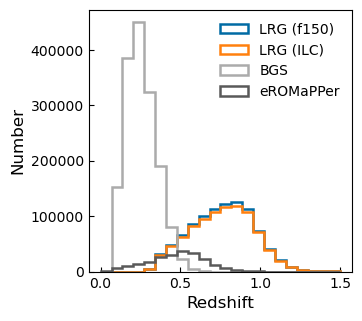

In [6]:
catalogs = {}
catalogs['lrg_sf'] = pd.read_csv('/work/jem189/scratch/data/catalogs/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radioflagged.csv')
catalogs['lrg_ilc'] = pd.read_csv('/work/jem189/scratch/data/catalogs/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc_radioflagged.csv')
catalogs['bgs'] = pd.read_csv('/work/jem189/scratch/data/catalogs/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radioflagged.csv')
catalogs['opt'] = pd.read_csv('/work/jem189/scratch/data/catalogs/iskay_RM_ls10_iron_v1_CGz_cat_310525_radioflagged.csv')

lrg_f150_z = catalogs['lrg_sf'].query('lum>3.58e10')['z'].values # should be len 957,095
lrg_ilc_z = catalogs['lrg_ilc'].query('lum>3.58e10')['z'].values # should be len 913,286
bgs_z = catalogs['bgs'].query('logm>10')['z'].values # should be len 1,610,381
opt_z = catalogs['opt'].query('lum>3.95')['z'].values # should be len 220,698

# --- Fonts / style (ApJ-friendly) ---
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# Single-column ApJ width (~3.4 in)
fig, ax = plt.subplots(figsize=(3.4, 3.4))

# Common binning (important for comparison)
all_z = np.concatenate([lrg_f150_z, lrg_ilc_z, bgs_z, opt_z])
nbins = int(1 + np.log2(len(all_z)))
bins = np.histogram_bin_edges(all_z, bins=nbins)

# Step histograms (print-safe)
n_lrg_sf, bins_lrg_sf, patches = ax.hist(lrg_f150_z, bins=bins, histtype='step', linewidth=1.8, label='LRG (f150)')
n_lrg_ilc, bins_lrg_ilc, patches = ax.hist(lrg_ilc_z,  bins=bins, histtype='step', linewidth=1.8, label='LRG (ILC)')
n_bgs, bins_bgs, patches = ax.hist(bgs_z, bins=bins, histtype='step', linewidth=1.8, label='BGS')
n_opt, bins_opt, patches = ax.hist(opt_z, bins=bins, histtype='step', linewidth=1.8, label='eROMaPPer')

# Labels
ax.set_xlabel('Redshift')
ax.set_ylabel('Number')

# Legend
ax.legend(frameon=False)

# Clean look
ax.tick_params(direction='in', top=False, right=False)

plt.savefig('figures/Figure2.pdf', bbox_inches='tight')

In [11]:
len(lrg_f150_z), len(lrg_ilc_z), len(bgs_z), len(opt_z)

(957095, 913286, 1610381, 220698)

In [22]:
fig2_df = pd.DataFrame()
fig2_df['zbin'] = bins_lrg_sf[:-1] # all samples have the same bins, remove the last one (which is just the upper edge of the last bin) to make all cols same size
fig2_df['N_lrg_f150'] = n_lrg_sf
fig2_df['N_lrg_ilc'] = n_lrg_ilc
fig2_df['N_bgs'] = n_bgs
fig2_df['N_optical'] = n_opt

In [24]:
fig2_df.to_csv('figure_data/figure2.csv', index=False)

# Figure 3

In [7]:
lrg_stacks = {}
lrg_stacks['f090'] = fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_act-planck_dr6.02_coadd_AA_night_f090_map_L35_stack.fits')
lrg_stacks['f150'] = fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_act-planck_dr6.02_coadd_AA_night_f150_map_L35_stack.fits')
lrg_stacks['ilc'] = fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc_ilc_SZ_yy_L35_stack.fits')
lrg_stacks['ilc_cib'] = fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc_ilc_SZ_deproj_cib_1.6_10.7_yy_L35_stack.fits')
lrg_stacks['ilc_db'] = fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc_ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy_L35_stack.fits')

bgs_stacks = {}
bgs_stacks['f090'] = fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_act-planck_dr6.02_coadd_AA_night_f090_map_10_stack.fits')
bgs_stacks['f150'] = fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_act-planck_dr6.02_coadd_AA_night_f150_map_10_stack.fits')
bgs_stacks['ilc'] = fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_ilc_SZ_yy_10_stack.fits')
bgs_stacks['ilc_cib'] = fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_ilc_SZ_deproj_cib_1.6_10.7_yy_10_stack.fits')
bgs_stacks['ilc_db'] = fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy_10_stack.fits')

opt_stacks = {}
opt_stacks['f090'] = fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525/iskay_RM_ls10_iron_v1_CGz_cat_310525_act-planck_dr6.02_coadd_AA_night_f090_map_stack.fits')
opt_stacks['f150'] = fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525/iskay_RM_ls10_iron_v1_CGz_cat_310525_act-planck_dr6.02_coadd_AA_night_f150_map_stack.fits')
opt_stacks['ilc'] = fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525/iskay_RM_ls10_iron_v1_CGz_cat_310525_ilc_SZ_yy_stack.fits')
opt_stacks['ilc_cib'] = fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525/iskay_RM_ls10_iron_v1_CGz_cat_310525_ilc_SZ_deproj_cib_1.6_10.7_yy_stack.fits')
opt_stacks['ilc_db'] = fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525/iskay_RM_ls10_iron_v1_CGz_cat_310525_ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy_stack.fits')


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


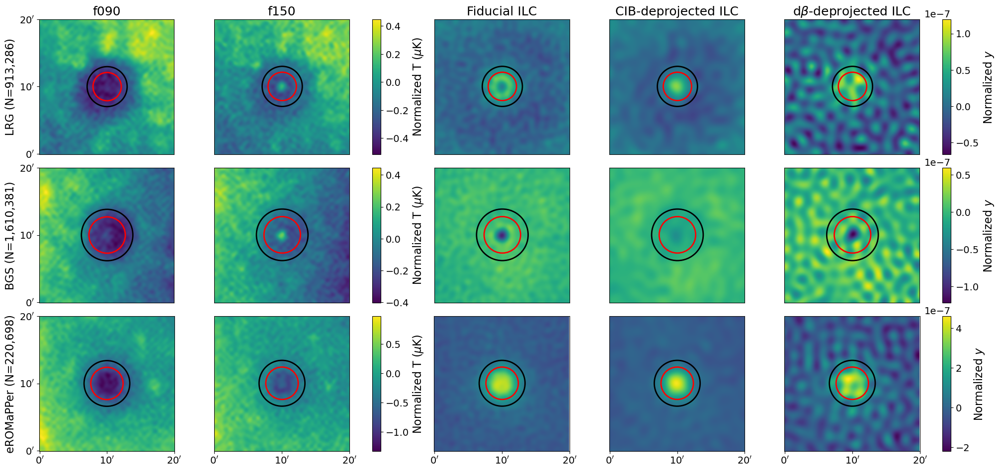

In [8]:
plt.rcParams.update({
    'font.size': 16,        # base size → 8 pt final
    'axes.titlesize': 18,   # → 9 pt final
    'axes.labelsize': 16,   # → 8 pt final
    'xtick.labelsize': 14,  # → 7 pt final
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
})

fig = plt.figure(figsize=(21,10))

gs = fig.add_gridspec(
    3, 8,
    width_ratios=[1, 1, 0.05, 0.15, 1, 1, 1, 0.05],
    left=0.08, right=0.97, bottom=0.08, top=0.95,
    wspace=0.05, hspace=0.1
)

# image axes
axs = np.empty((3, 7), dtype=object)
for r in range(3):
    for c in [0,1,4,5,6]:
        axs[r, c] = fig.add_subplot(gs[r, c])
        
labels = ['f090', 'f150']
aps = [2.1, 2.7, 2.4]

for j, stacks in enumerate([lrg_stacks, bgs_stacks, opt_stacks]):
    # plot f090/f150 images with one shared colorbar
    mins = []
    maxs = []
    sf_stacks = [stacks['f090'], stacks['f150']]
    for stack in sf_stacks:
        mins.append(np.min(stack-np.mean(stack)))
        maxs.append(np.max(stack-np.mean(stack)))
    cbar_norm = Normalize(vmin=np.min(mins), vmax=np.max(maxs))
    images = []
    for i, stack in enumerate(sf_stacks):
        r_rad_submap = np.deg2rad(10/60.)
        pixel_size = (r_rad_submap*2/np.shape(stack)[0])*10800/np.pi
        ax = axs[j, i]
        im = ax.imshow(
            stack - np.mean(stack),
            origin='lower',
            norm=cbar_norm, cmap='viridis')
        images.append(im)
        disk = plt.Circle((np.shape(stack)[0]/2., np.shape(stack)[1]/2.), aps[j]/pixel_size, color='red', fill=False, lw=2)
        disk2 = plt.Circle((np.shape(stack)[0]/2., np.shape(stack)[1]/2.), np.sqrt(2)*aps[j]/pixel_size, color='black', fill=False, lw=2)
        ax.add_patch(disk)
        ax.add_patch(disk2)
        if j == 0:
            ax.set_title(labels[i])
        ax.set_xticks([],[])
        ax.set_yticks([],[])
    # colorbar axis (spans both rows)
    cax = fig.add_subplot(gs[j, 2])
    cbar = fig.colorbar(images[0], cax=cax)
    cbar.ax.tick_params(labelsize=14)   # (or 7 at final scale)
    cbar.set_label(r'Normalized T ($\mu$K)', fontsize=16)

    # now do ILC
    labels = ['Fiducial ILC', 'CIB-deprojected ILC', r'd$\beta$-deprojected ILC']
    mins = []
    maxs = []
    ilc_stacks = [stacks['ilc'], stacks['ilc_cib'], stacks['ilc_db']]
    for stack in ilc_stacks:
        mins.append(np.min(stack-np.mean(stack)))
        maxs.append(np.max(stack-np.mean(stack)))
    cbar_norm = Normalize(vmin=np.min(mins), vmax=np.max(maxs))
    images = []
    for i, stack in enumerate(ilc_stacks):
        ax = axs[j, i+4]
        r_rad_submap = np.deg2rad(10/60.)
        pixel_size = (r_rad_submap*2/np.shape(stack)[0])*10800/np.pi
        im = ax.imshow(
            stack - np.mean(stack),
            origin='lower',
            norm=cbar_norm, cmap='viridis')
        images.append(im)
        disk = plt.Circle((np.shape(stack)[0]/2., np.shape(stack)[1]/2.), aps[j]/pixel_size, color='red', fill=False, lw=2)
        disk2 = plt.Circle((np.shape(stack)[0]/2., np.shape(stack)[1]/2.), np.sqrt(2)*aps[j]/pixel_size, color='black', fill=False, lw=2)
        ax.add_patch(disk)
        ax.add_patch(disk2)
        if j == 0:
            ax.set_title(labels[i])
        ax.set_xticks([],[])
        ax.set_yticks([],[])
    # colorbar axis (spans both rows)
    cax = fig.add_subplot(gs[j, 7])
    cbar = fig.colorbar(images[0], cax=cax)
    cbar.ax.tick_params(labelsize=14)   # (or 7 at final scale)
    cbar.set_label(r'Normalized $y$', fontsize=16)

# do axis labels
for ax in axs[:, 0]:
    ax.set_yticks(
        np.array([0, 10, 20]) / pixel_size,
        labels=[r"$0'$", r"$10'$", r"$20'$"])
for ax in axs[2, :2]:
    ax.set_xticks(
        np.array([0, 10, 20]) / pixel_size,
        labels=[r"$0'$", r"$10'$", r"$20'$"])
for ax in axs[2, 4:7]:
    ax.set_xticks(
        np.array([0, 10, 20]) / pixel_size,
        labels=[r"$0'$", r"$10'$", r"$20'$"])
axs[0, 0].set_ylabel('LRG (N=913,286)')
axs[1, 0].set_ylabel('BGS (N=1,610,381)')
axs[2, 0].set_ylabel('eROMaPPer (N=220,698)')

plt.savefig('figures/Figure3.pdf', bbox_inches='tight') 

In [43]:
np.savez('figure_data/figure3_lrg.npz', lrg_f090=lrg_stacks['f090'], lrg_f150=lrg_stacks['f150'], lrg_ilc=lrg_stacks['ilc'], lrg_ilc_cib=lrg_stacks['ilc_cib'], lrg_ilc_db=lrg_stacks['ilc_db'])
np.savez('figure_data/figure3_bgs.npz', bgs_f090=bgs_stacks['f090'], bgs_f150=bgs_stacks['f150'], bgs_ilc=bgs_stacks['ilc'], bgs_ilc_cib=bgs_stacks['ilc_cib'], bgs_ilc_db=bgs_stacks['ilc_db'])
np.savez('figure_data/figure3_opt.npz', opt_f090=opt_stacks['f090'], opt_f150=opt_stacks['f150'], opt_ilc=opt_stacks['ilc'], opt_ilc_cib=opt_stacks['ilc_cib'], opt_ilc_db=opt_stacks['ilc_db'])

# Figure 4

In [9]:
lrg_profiles = {}
bgs_profiles = {}
opt_profiles = {}
for f in ['f090', 'f150']:
    lrg_profiles[f] = pd.read_csv(f'profiles/{f}_lrg_L36_profiles.csv', index_col=0)
    bgs_profiles[f] = pd.read_csv(f'profiles/{f}_bgs_M10_profiles.csv', index_col=0)
    opt_profiles[f] = pd.read_csv(f'profiles/{f}_opt_L5_profiles.csv', index_col=0)

In [10]:
profile_data = {}
profile_data['lrg'] = {}
profile_data['bgs'] = {}
profile_data['opt'] = {}
for f in ['f090', 'f150']:
    profile_data['lrg'][f] = np.asarray([lrg_profiles[f]['radius'].values, lrg_profiles[f]['dy_bc'].values, lrg_profiles[f]['dy_err_bc'].values])
    profile_data['bgs'][f] = np.asarray([bgs_profiles[f]['radius'].values, bgs_profiles[f]['dy_bc'].values, bgs_profiles[f]['dy_err_bc'].values])
    profile_data['opt'][f] = np.asarray([opt_profiles[f]['radius'].values, opt_profiles[f]['dy_bc'].values, opt_profiles[f]['dy_err_bc'].values])

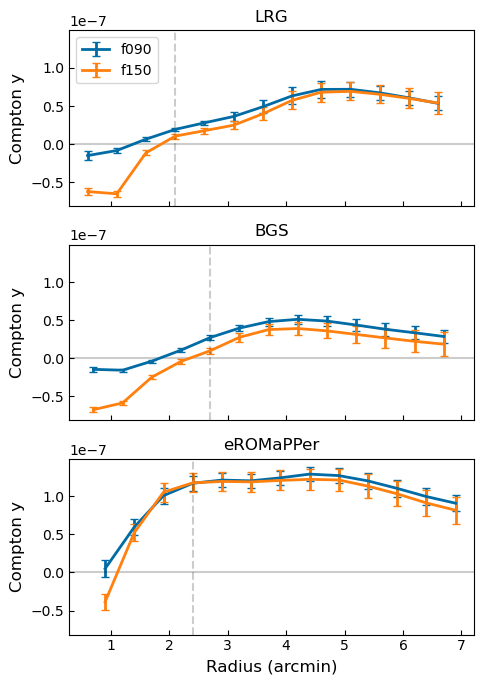

In [11]:
# --- ApJ-style rcParams ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
aps = [2.1, 2.7, 2.4]
titles = ['LRG', 'BGS', 'eROMaPPer']
labels = ['f090', 'f150']
fig, axs = plt.subplots(3, 1, figsize=[5, 7], sharex=True, sharey=True)
for l, m in enumerate(['lrg', 'bgs', 'opt']):
    for j, k in enumerate(labels):
        axs[l].errorbar(profile_data[m][k][0], profile_data[m][k][1], yerr=profile_data[m][k][2], label=k, color=colors[j], lw=2, capsize=3)
    axs[l].set_title(titles[l])
    axs[l].axvline(aps[l], ls='--', color='black', alpha=0.2)
for ax in axs:
    ax.set_ylabel('Compton y')
axs[-1].set_xlabel('Radius (arcmin)')
for ax in axs.flatten():
    ax.axhline(0, color='black', alpha=0.2)
plt.tight_layout()
axs[0].legend(loc='upper left')
plt.savefig('figures/Figure4.pdf', bbox_inches='tight', pad_inches=0.1)

In [43]:
np.savez('figure_data/figure4_lrg.npz', lrg_f090=profile_data['lrg']['f090'], lrg_f150=profile_data['lrg']['f150'])
np.savez('figure_data/figure4_bgs.npz', bgs_f090=profile_data['bgs']['f090'], bgs_f150=profile_data['bgs']['f150'])
np.savez('figure_data/figure4_opt.npz', opt_f090=profile_data['opt']['f090'], lrg_f150=profile_data['opt']['f150'])

# Figure 5

In [5]:
lrg_profiles = {}
bgs_profiles = {}
opt_profiles = {}
for f in ['ilc', 'ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']:
    lrg_profiles[f] = pd.read_csv(f'profiles/{f}_lrg_L36_profiles.csv', index_col=0)
    bgs_profiles[f] = pd.read_csv(f'profiles/{f}_bgs_M10_profiles.csv', index_col=0)
    opt_profiles[f] = pd.read_csv(f'profiles/{f}_opt_L5_profiles.csv', index_col=0)

In [6]:
profile_data = {}
profile_data['lrg'] = {}
profile_data['bgs'] = {}
profile_data['opt'] = {}
for f in ['ilc', 'ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']:
    profile_data['lrg'][f] = np.asarray([lrg_profiles[f]['radius'].values, lrg_profiles[f]['dy_bc'].values, lrg_profiles[f]['dy_err_bc'].values])
    profile_data['bgs'][f] = np.asarray([bgs_profiles[f]['radius'].values, bgs_profiles[f]['dy_bc'].values, bgs_profiles[f]['dy_err_bc'].values])
    profile_data['opt'][f] = np.asarray([opt_profiles[f]['radius'].values, opt_profiles[f]['dy_bc'].values, opt_profiles[f]['dy_err_bc'].values])

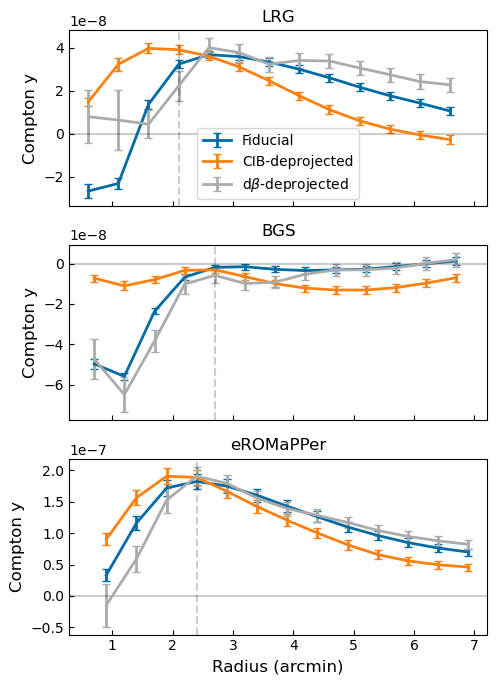

In [7]:
# --- ApJ-style rcParams ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
aps = [2.1, 2.7, 2.4]
titles = ['LRG', 'BGS', 'eROMaPPer']
names = ['Fiducial', 'CIB-deprojected', r'd$\beta$-deprojected']
labels = ['ilc', 'ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']
fig, axs = plt.subplots(3, 1, figsize=[5, 7], sharex=True, sharey=False)
for l, m in enumerate(['lrg', 'bgs', 'opt']):
    for j, k in enumerate(labels):
        axs[l].errorbar(profile_data[m][k][0], profile_data[m][k][1], yerr=profile_data[m][k][2], label=names[j], color=colors[j], lw=2, capsize=3)
    axs[l].set_title(titles[l])
    axs[l].axvline(aps[l], ls='--', color='black', alpha=0.2)
for ax in axs:
    ax.set_ylabel('Compton y')
axs[-1].set_xlabel('Radius (arcmin)')
for ax in axs.flatten():
    ax.axhline(0, color='black', alpha=0.2)
plt.tight_layout()
axs[0].legend()
plt.savefig('figures/Figure5.pdf', bbox_inches='tight', pad_inches=0.1)

In [56]:
np.savez('figure_data/figure5_lrg.npz', lrg_ilc=profile_data['lrg']['ilc'], lrg_cib_deproj=profile_data['lrg']['ilc_cib_1.6_10.7'], lrg_db_deproj=profile_data['lrg']['ilc_db_1.6_10.7'])
np.savez('figure_data/figure5_bgs.npz', bgs_ilc=profile_data['bgs']['ilc'], bgs_cib_deproj=profile_data['bgs']['ilc_cib_1.6_10.7'], bgs_db_deproj=profile_data['bgs']['ilc_db_1.6_10.7'])
np.savez('figure_data/figure5_opt.npz', opt_ilc=profile_data['opt']['ilc'], lrg_cib_deproj=profile_data['opt']['ilc_cib_1.6_10.7'], opt_db_deproj=profile_data['opt']['ilc_db_1.6_10.7'])

# Figure 21 (was Figure 6 in original draft)

In [16]:
lrg_profiles = {}
bgs_profiles = {}
opt_profiles = {}
for f in ['ilc', 'ilc_cib_1.2_10.7', 'ilc_cib_1.4_10.7', 'ilc_cib_1.6_10.7', 'ilc_db_1.2_10.7', 'ilc_db_1.4_10.7', 'ilc_db_1.6_10.7']:
    lrg_profiles[f] = pd.read_csv(f'profiles/{f}_lrg_L36_profiles.csv', index_col=0)
    bgs_profiles[f] = pd.read_csv(f'profiles/{f}_bgs_M10_profiles.csv', index_col=0)
    opt_profiles[f] = pd.read_csv(f'profiles/{f}_opt_L5_profiles.csv', index_col=0)

In [17]:
profile_data = {}
profile_data['lrg'] = {}
profile_data['bgs'] = {}
profile_data['opt'] = {}
for f in ['ilc', 'ilc_cib_1.2_10.7', 'ilc_cib_1.4_10.7', 'ilc_cib_1.6_10.7', 'ilc_db_1.2_10.7', 'ilc_db_1.4_10.7', 'ilc_db_1.6_10.7']:
    profile_data['lrg'][f] = np.asarray([lrg_profiles[f]['radius'].values, lrg_profiles[f]['dy'].values, lrg_profiles[f]['dy_err'].values])
    profile_data['bgs'][f] = np.asarray([bgs_profiles[f]['radius'].values, bgs_profiles[f]['dy'].values, bgs_profiles[f]['dy_err'].values])
    profile_data['opt'][f] = np.asarray([opt_profiles[f]['radius'].values, opt_profiles[f]['dy'].values, opt_profiles[f]['dy_err'].values])

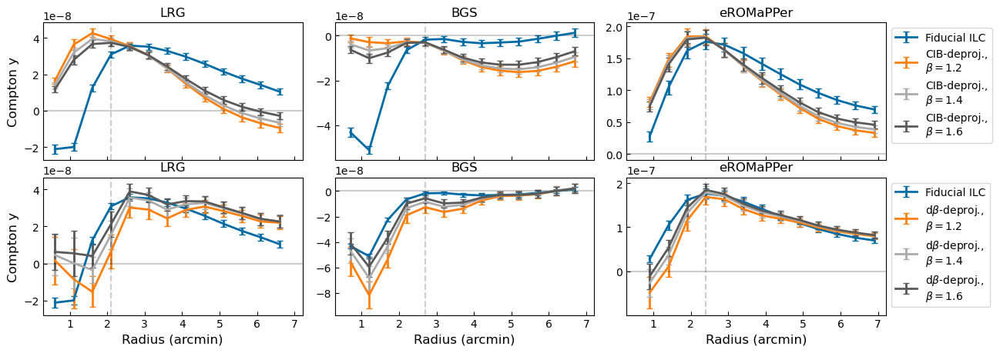

In [18]:

# --- ApJ-style rcParams ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 20,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

aps = [2.1, 2.7, 2.4]
titles = ['LRG', 'BGS', 'eROMaPPer']
names = ['CIB-deproj.,\n', r'd$\beta$'+'-deproj.,\n']
labels = [r'$\beta=1.2$', r'$\beta=1.4$', r'$\beta=1.6$']
ls = ['ilc', 'ilc_cib_1.2_10.7', 'ilc_cib_1.4_10.7', 'ilc_cib_1.6_10.7', 'ilc_db_1.2_10.7', 'ilc_db_1.4_10.7', 'ilc_db_1.6_10.7']
fig, axs = plt.subplots(2, 3, figsize=[12, 5], sharex=True, sharey=False)

for l, m in enumerate(['lrg', 'bgs', 'opt']):
    for ax in axs[:, l]:
        ax.errorbar(profile_data[m]['ilc'][0], profile_data[m]['ilc'][1], yerr=profile_data[m]['ilc'][2], label='Fiducial ILC', color=colors[0], lw=2, capsize=3)

for l, m in enumerate(['lrg', 'bgs', 'opt']):
    for j, k in enumerate(ls[1:4]):
        axs[0, l].errorbar(profile_data[m][k][0], profile_data[m][k][1], yerr=profile_data[m][k][2], label=names[0]+labels[j], color=colors[j+1], lw=2, capsize=3)
    axs[0, l].set_title(titles[l])
    axs[0, l].axvline(aps[l], ls='--', color='black', alpha=0.2)
    for j, k in enumerate(ls[4:]):
        axs[1, l].errorbar(profile_data[m][k][0], profile_data[m][k][1], yerr=profile_data[m][k][2], label=names[1]+labels[j], color=colors[j+1], lw=2, capsize=3)
    axs[1, l].set_title(titles[l])
    axs[1, l].axvline(aps[l], ls='--', color='black', alpha=0.2)
axs[0,0].set_ylabel('Compton y')
axs[1,0].set_ylabel('Compton y')

for ax in axs[1, :]:
    ax.set_xlabel('Radius (arcmin)')
for ax in axs.flatten():
    ax.axhline(0, color='black', alpha=0.2)
plt.tight_layout()

axs[0,2].legend(bbox_to_anchor=[1,1])
axs[1,2].legend(bbox_to_anchor=[1,1])
plt.subplots_adjust(wspace=0.125, hspace=0.125)
plt.savefig('figures/Figure21.pdf', bbox_inches='tight', pad_inches=0.1)
# plt.savefig('allsamples_yprofiles_cibanddbdeproj_betacompare_fullsample_y.pdf', bbox_inches='tight', pad_inches=0.1)

In [19]:
np.savez('figure_data/figure21_lrg.npz', lrg_ilc=profile_data['lrg']['ilc'], lrg_cib_deproj_1p2=profile_data['lrg']['ilc_cib_1.2_10.7'], lrg_cib_deproj_1p4=profile_data['lrg']['ilc_cib_1.4_10.7'], lrg_cib_deproj_1p6=profile_data['lrg']['ilc_cib_1.6_10.7'], lrg_db_deproj_1p2=profile_data['lrg']['ilc_db_1.2_10.7'], lrg_db_deproj_1p4=profile_data['lrg']['ilc_db_1.4_10.7'], lrg_db_deproj_1p6=profile_data['lrg']['ilc_db_1.6_10.7'])
np.savez('figure_data/figure21_bgs.npz', bgs_ilc=profile_data['bgs']['ilc'], bgs_cib_deproj_1p2=profile_data['bgs']['ilc_cib_1.2_10.7'], bgs_cib_deproj_1p4=profile_data['bgs']['ilc_cib_1.4_10.7'], bgs_cib_deproj_1p6=profile_data['bgs']['ilc_cib_1.6_10.7'], bgs_db_deproj_1p2=profile_data['bgs']['ilc_db_1.2_10.7'], bgs_db_deproj_1p4=profile_data['bgs']['ilc_db_1.4_10.7'], bgs_db_deproj_1p6=profile_data['bgs']['ilc_db_1.6_10.7'])
np.savez('figure_data/figure21_opt.npz', opt_ilc=profile_data['opt']['ilc'], opt_cib_deproj_1p2=profile_data['opt']['ilc_cib_1.2_10.7'], opt_cib_deproj_1p4=profile_data['opt']['ilc_cib_1.4_10.7'], opt_cib_deproj_1p6=profile_data['opt']['ilc_cib_1.6_10.7'], opt_db_deproj_1p2=profile_data['opt']['ilc_db_1.2_10.7'], opt_db_deproj_1p4=profile_data['opt']['ilc_db_1.4_10.7'], opt_db_deproj_1p6=profile_data['opt']['ilc_db_1.6_10.7'])

# Figure 22 (was Figure 7 in original draft)

In [20]:
lrg_profiles = {}
bgs_profiles = {}
opt_profiles = {}
for f in ['ilc', 'ilc_cib_1.6_10.7', 'ilc_cib_1.6_24.0', 'ilc_db_1.6_10.7', 'ilc_db_1.6_24.0']:
    lrg_profiles[f] = pd.read_csv(f'profiles/{f}_lrg_L36_profiles.csv', index_col=0)
    bgs_profiles[f] = pd.read_csv(f'profiles/{f}_bgs_M10_profiles.csv', index_col=0)
    opt_profiles[f] = pd.read_csv(f'profiles/{f}_opt_L5_profiles.csv', index_col=0)

In [21]:
profile_data = {}
profile_data['lrg'] = {}
profile_data['bgs'] = {}
profile_data['opt'] = {}
for f in ['ilc', 'ilc_cib_1.6_10.7', 'ilc_cib_1.6_24.0', 'ilc_db_1.6_10.7', 'ilc_db_1.6_24.0']:
    profile_data['lrg'][f] = np.asarray([lrg_profiles[f]['radius'].values, lrg_profiles[f]['dy'].values, lrg_profiles[f]['dy_err'].values])
    profile_data['bgs'][f] = np.asarray([bgs_profiles[f]['radius'].values, bgs_profiles[f]['dy'].values, bgs_profiles[f]['dy_err'].values])
    profile_data['opt'][f] = np.asarray([opt_profiles[f]['radius'].values, opt_profiles[f]['dy'].values, opt_profiles[f]['dy_err'].values])

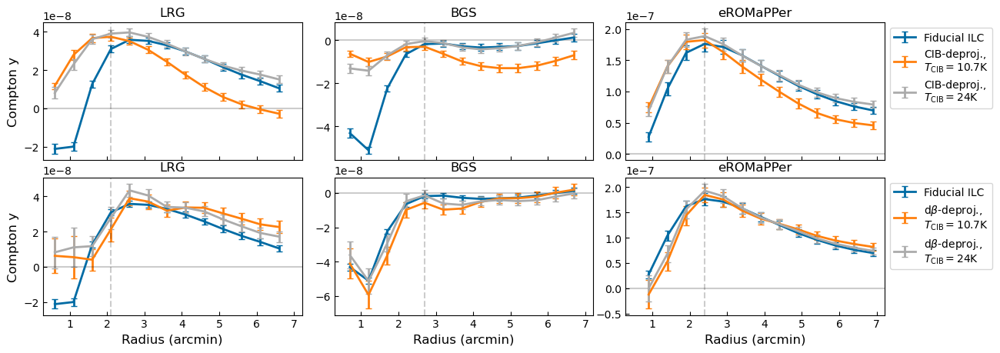

In [22]:
# --- ApJ-style rcParams ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 20,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

aps = [2.1, 2.7, 2.4]
titles = ['LRG', 'BGS', 'eROMaPPer']
names = ['CIB-deproj.,\n', r'd$\beta$'+'-deproj.,\n']
labels = [r'$T_{\mathrm{CIB}}=10.7$K', r'$T_{\mathrm{CIB}}=24$K']
ls = ['ilc', 'ilc_cib_1.6_10.7', 'ilc_cib_1.6_24.0', 'ilc_db_1.6_10.7', 'ilc_db_1.6_24.0']
fig, axs = plt.subplots(2, 3, figsize=[12, 5], sharex=True, sharey=False)

for l, m in enumerate(['lrg', 'bgs', 'opt']):
    for ax in axs[:, l]:
        ax.errorbar(profile_data[m]['ilc'][0], profile_data[m]['ilc'][1], yerr=profile_data[m]['ilc'][2], label='Fiducial ILC', color=colors[0], lw=2, capsize=3)

for l, m in enumerate(['lrg', 'bgs', 'opt']):
    for j, k in enumerate(ls[1:3]):
        axs[0, l].errorbar(profile_data[m][k][0], profile_data[m][k][1], yerr=profile_data[m][k][2], label=names[0]+labels[j], color=colors[j+1], lw=2, capsize=3)
    axs[0, l].set_title(titles[l])
    axs[0, l].axvline(aps[l], ls='--', color='black', alpha=0.2)
    for j, k in enumerate(ls[3:]):
        axs[1, l].errorbar(profile_data[m][k][0], profile_data[m][k][1], yerr=profile_data[m][k][2], label=names[1]+labels[j], color=colors[j+1], lw=2, capsize=3)
    axs[1, l].set_title(titles[l])
    axs[1, l].axvline(aps[l], ls='--', color='black', alpha=0.2)
axs[0,0].set_ylabel('Compton y')
axs[1,0].set_ylabel('Compton y')

for ax in axs[1, :]:
    ax.set_xlabel('Radius (arcmin)')
for ax in axs.flatten():
    ax.axhline(0, color='black', alpha=0.2)
plt.tight_layout()

axs[0,2].legend(bbox_to_anchor=[1,1])
axs[1,2].legend(bbox_to_anchor=[1,1])
plt.subplots_adjust(wspace=0.125, hspace=0.125)
plt.savefig('figures/Figure22.pdf', bbox_inches='tight', pad_inches=0.1)
# plt.savefig('allsamples_yprofiles_cibanddbdeproj_tempcompare_fullsample_y.pdf', bbox_inches='tight', pad_inches=0.1)

In [23]:
np.savez('figure_data/figure22_lrg.npz', lrg_ilc=profile_data['lrg']['ilc'], lrg_cib_deproj_10p7=profile_data['lrg']['ilc_cib_1.6_10.7'], lrg_cib_deproj_24p0=profile_data['lrg']['ilc_cib_1.6_24.0'], lrg_db_deproj_10p7=profile_data['lrg']['ilc_db_1.6_10.7'], lrg_db_deproj_24p0=profile_data['lrg']['ilc_db_1.6_24.0'])
np.savez('figure_data/figure22_bgs.npz', bgs_ilc=profile_data['bgs']['ilc'], bgs_cib_deproj_10p7=profile_data['bgs']['ilc_cib_1.6_10.7'], bgs_cib_deproj_24p0=profile_data['bgs']['ilc_cib_1.6_24.0'], bgs_db_deproj_10p7=profile_data['bgs']['ilc_db_1.6_10.7'], bgs_db_deproj_24p0=profile_data['bgs']['ilc_db_1.6_24.0'])
np.savez('figure_data/figure22_opt.npz', opt_ilc=profile_data['opt']['ilc'], opt_cib_deproj_10p7=profile_data['opt']['ilc_cib_1.6_10.7'], opt_cib_deproj_24p0=profile_data['opt']['ilc_cib_1.6_24.0'], opt_db_deproj_10p7=profile_data['opt']['ilc_db_1.6_10.7'], opt_db_deproj_24p0=profile_data['opt']['ilc_db_1.6_24.0'])

# Figure 6

In [24]:
lrg_profiles = {}
bgs_profiles = {}
opt_profiles = {}
for f in ['f090', 'f150']:
    lrg_profiles[f] = pd.read_csv(f'profiles/{f}_lrg_L36_rr_profiles.csv', index_col=0)
    bgs_profiles[f] = pd.read_csv(f'profiles/{f}_bgs_M10_rr_profiles.csv', index_col=0)
    opt_profiles[f] = pd.read_csv(f'profiles/{f}_opt_L5_rr_profiles.csv', index_col=0)

In [25]:
profile_data = {}
profile_data['lrg'] = {}
profile_data['bgs'] = {}
profile_data['opt'] = {}
for f in ['f090', 'f150']:
    profile_data['lrg'][f] = np.asarray([lrg_profiles[f]['radius'].values, lrg_profiles[f]['dy_bc'].values, lrg_profiles[f]['dy_err_bc'].values])
    profile_data['bgs'][f] = np.asarray([bgs_profiles[f]['radius'].values, bgs_profiles[f]['dy_bc'].values, bgs_profiles[f]['dy_err_bc'].values])
    profile_data['opt'][f] = np.asarray([opt_profiles[f]['radius'].values, opt_profiles[f]['dy_bc'].values, opt_profiles[f]['dy_err_bc'].values])

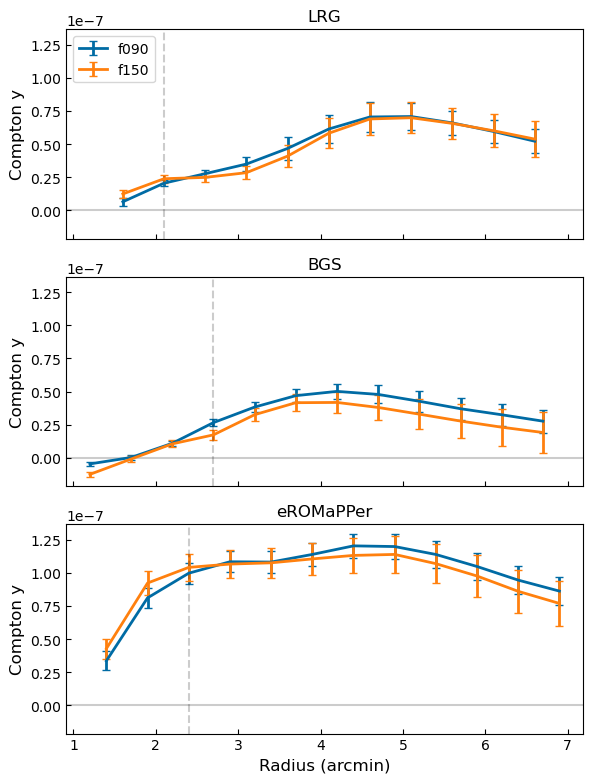

In [26]:
# --- ApJ-style rcParams ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
aps = [2.1, 2.7, 2.4]
titles = ['LRG', 'BGS', 'eROMaPPer']
labels = ['f090', 'f150']
fig, axs = plt.subplots(3, 1, figsize=[6, 8], sharex=True, sharey=True)
for l, m in enumerate(['lrg', 'bgs', 'opt']):
    for j, k in enumerate(labels):
        axs[l].errorbar(profile_data[m][k][0], profile_data[m][k][1], yerr=profile_data[m][k][2], label=labels[j], color=colors[j], lw=2, capsize=3)
    axs[l].set_title(titles[l])
    axs[l].axvline(aps[l], ls='--', color='black', alpha=0.2)
for ax in axs:
    ax.set_ylabel('Compton y')
axs[-1].set_xlabel('Radius (arcmin)')
for ax in axs.flatten():
    ax.axhline(0, color='black', alpha=0.2)
plt.tight_layout()
axs[0].legend(loc='upper left')
plt.savefig('figures/Figure6.pdf', bbox_inches='tight', pad_inches=0.1)

In [27]:
np.savez('figure_data/figure6_lrg.npz', lrg_f090=profile_data['lrg']['f090'], lrg_f150=profile_data['lrg']['f150'])
np.savez('figure_data/figure6_bgs.npz', bgs_f090=profile_data['bgs']['f090'], bgs_f150=profile_data['bgs']['f150'])
np.savez('figure_data/figure6_opt.npz', opt_f090=profile_data['opt']['f090'], opt_f150=profile_data['opt']['f150'])

# Figure 7

In [28]:
lrg_profiles = pd.read_csv('profiles/f220_lrg_L36_profiles.csv', index_col=0)
bgs_profiles = pd.read_csv('profiles/f220_bgs_M10_profiles.csv', index_col=0)
opt_profiles = pd.read_csv('profiles/f220_opt_L5_profiles.csv', index_col=0)

In [29]:
lrg_stack = fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_act-planck_dr6.02_coadd_AA_night_f220_map_L35_stack.fits')
bgs_stack = fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_act-planck_dr6.02_coadd_AA_night_f220_map_10_stack.fits')
opt_stack = fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525/iskay_RM_ls10_iron_v1_CGz_cat_310525_act-planck_dr6.02_coadd_AA_night_f220_map_stack.fits')

In [30]:
profile_data = {}
profile_data['lrg'] = np.asarray([lrg_profiles['radius'].values, lrg_profiles['dT'].values, lrg_profiles['dT_err'].values])
profile_data['bgs'] = np.asarray([bgs_profiles['radius'].values, bgs_profiles['dT'].values, bgs_profiles['dT_err'].values])
profile_data['opt'] = np.asarray([opt_profiles['radius'].values, opt_profiles['dT'].values, opt_profiles['dT_err'].values])

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


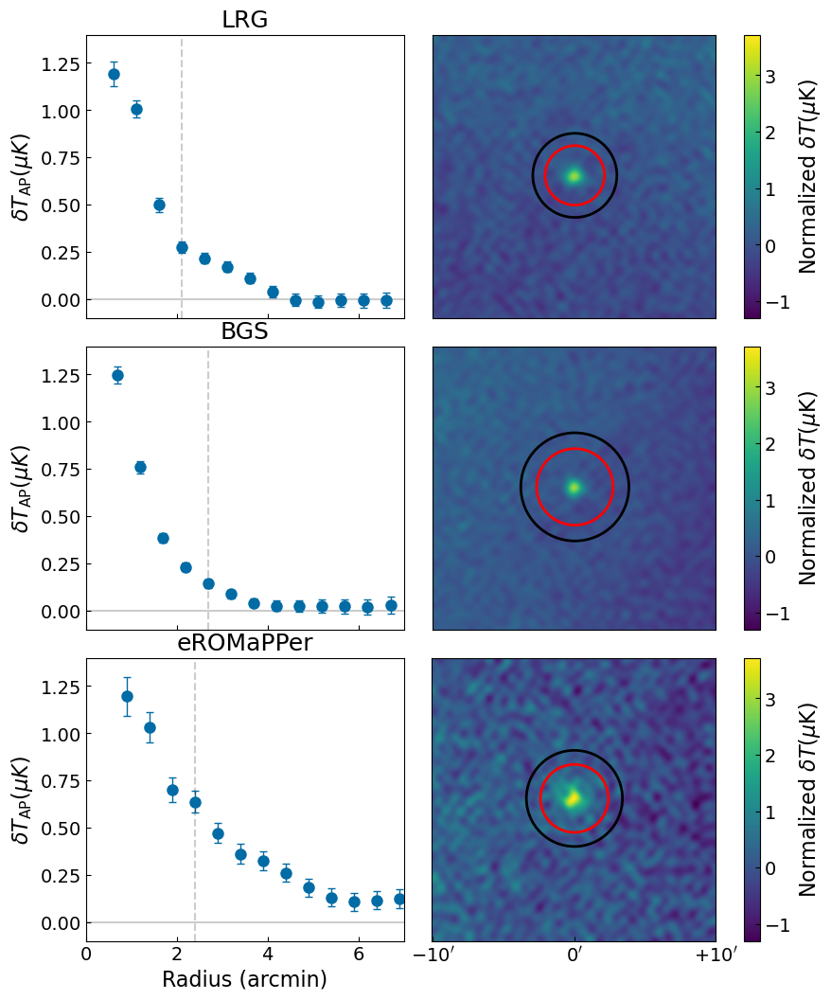

In [31]:
plt.rcParams.update({
    'font.size': 16,        # base size → 8 pt final
    'axes.titlesize': 18,   # → 9 pt final
    'axes.labelsize': 16,   # → 8 pt final
    'xtick.labelsize': 14,  # → 7 pt final
    'ytick.labelsize': 14,
    'legend.fontsize': 14})
rs = [2.1, 2.7, 2.4]
fig = plt.figure(figsize=(8,11))
gs = fig.add_gridspec(3, 3, width_ratios=[1, 1, 0.05], left=0.08, right=0.97, bottom=0.08, top=0.95, wspace=0.05, hspace=0.1)
axs = np.empty((3, 3), dtype=object)
for r in range(3):
    for c in range(2):
        axs[r, c] = fig.add_subplot(gs[r, c])
labels = ['LRG', 'BGS', 'eROMaPPer']
# profiles
for l, m in enumerate(['lrg', 'bgs', 'opt']):
    axs[l, 0].errorbar(profile_data[m][0], profile_data[m][1], yerr=profile_data[m][2], **errbar_kwargs)
    axs[l, 0].set_title(labels[l])
    axs[l, 0].axvline(rs[l], ls='--', color='black', alpha=0.2)
for ax in axs[:, 0]:
    ax.set_xlim(0, 7)
    ax.set_ylim(-0.1, 1.4)
    ax.axhline(0, color='black', alpha=0.2)
    ax.set_ylabel(r'$\delta T_{\mathrm{AP}} (\mu K)$')
axs[0,0].axes.xaxis.set_ticklabels([])
axs[1,0].axes.xaxis.set_ticklabels([])
# images
mins = []
maxs = []
stacks = [lrg_stack, bgs_stack, opt_stack]
for stack in stacks:
    mins.append(np.min(stack.data-np.mean(stack.data)))
    maxs.append(np.max(stack.data-np.mean(stack.data)))
cbar_norm = Normalize(vmin=np.min(mins), vmax=np.max(maxs))
images = []
for i, stack in enumerate(stacks):
    ax = axs[i, 1]
    im = ax.imshow(stack.data-np.mean(stack.data), origin='lower', norm=cbar_norm, cmap='viridis')
    images.append(im)
    r_rad_submap = np.deg2rad(10./60.)
    pixel_size = (2*r_rad_submap/np.shape(stack)[0])*10800/np.pi
    disk = plt.Circle((np.shape(stack)[0]/2., np.shape(stack)[1]/2.), rs[i]/pixel_size, color='red', fill=False, lw=2)
    disk2 = plt.Circle((np.shape(stack)[0]/2., np.shape(stack)[1]/2.), np.sqrt(2)*rs[i]/pixel_size, color='black', fill=False, lw=2)
    ax.add_patch(disk)
    ax.add_patch(disk2)
    ax.set_xticks([], [])
    ax.set_yticks([],[])
    cax = fig.add_subplot(gs[i, 2])
    cbar = fig.colorbar(images[0], cax=cax)
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label(r'Normalized $\delta T (\mu$K)', fontsize=16)
axs[2, 0].set_xlabel('Radius (arcmin)')
axs[2, 1].set_xticks(np.array([0, 10, 20])/pixel_size, labels=[r"$-10'$", r"$0'$", r"$+10'$"])
plt.savefig('figures/Figure7.pdf', bbox_inches='tight')
# plt.savefig('/hpc/group/cosmology/jem189/scratch/plots/paper_plots_20260520/allsamples_fullsample_f220_stacked_images_normalized_andprofiles.pdf', bbox_inches='tight')

In [32]:
np.savez('figure_data/figure7_profiles.npz', lrg=profile_data['lrg'], bgs=profile_data['bgs'], optical=profile_data['opt'])
np.savez('figure_data/figure7_images.npz', lrg=lrg_stack, bgs=bgs_stack, optical=opt_stack)

# Figure 8

In [33]:
lrg_profiles = {}
bgs_profiles = {}
for f in ['f090', 'f150']:
    lrg_profiles[f] = pd.read_csv(f'profiles/{f}_lrg_L36_profile_deproj.csv')
    bgs_profiles[f] = pd.read_csv(f'profiles/{f}_bgs_M10_profile_deproj.csv')


In [34]:
profile_data = {}
profile_data['lrg'] = {}
profile_data['bgs'] = {}
for f in ['f090', 'f150']:
    profile_data['lrg'][f] = np.asarray([lrg_profiles[f]['radius'].values, lrg_profiles[f]['dy_deproj'].values, lrg_profiles[f]['dy_deproj_err'].values, lrg_profiles[f]['dy_bc'].values])
    profile_data['bgs'][f] = np.asarray([bgs_profiles[f]['radius'].values, bgs_profiles[f]['dy_deproj'].values, bgs_profiles[f]['dy_deproj_err'].values, bgs_profiles[f]['dy_bc'].values])


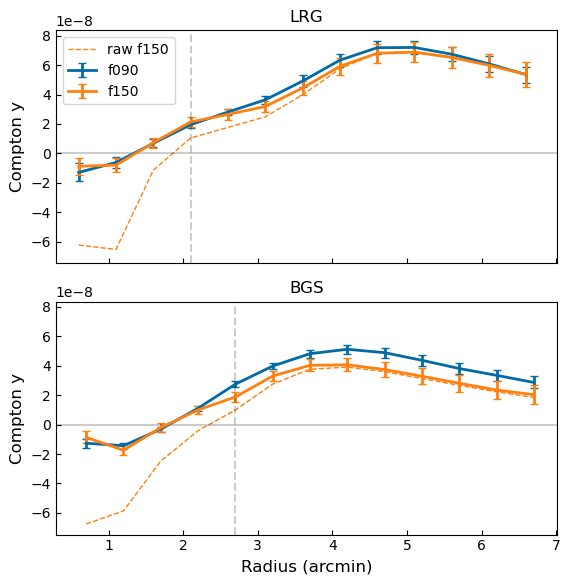

In [35]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

aps = [2.1, 2.7]
titles = ['LRG', 'BGS']
labels = ['f090', 'f150']
fig, axs = plt.subplots(2, 1, figsize=[6,6], sharex=True, sharey=True)
for l, m in enumerate(['lrg', 'bgs']):
    for j, k in enumerate(labels):
        axs[l].errorbar(profile_data[m][k][0], profile_data[m][k][1], yerr=profile_data[m][k][2], label=labels[j], color=colors[j], lw=2, capsize=3)
    axs[l].plot(profile_data[m]['f150'][0], profile_data[m]['f150'][3], label='raw f150', color=colors[1], lw=1, ls='dashed')
    axs[l].set_title(titles[l])
    axs[l].axvline(aps[l], ls='--', color='black', alpha=0.2)

axs[1].set_xlabel('Radius (arcmin)')
for ax in axs.flatten():
    ax.axhline(0, color='black', alpha=0.2)
    ax.set_ylabel('Compton y')
plt.tight_layout()

axs[0].legend(loc='upper left')
plt.savefig('figures/Figure8.pdf', bbox_inches='tight', pad_inches=0.1)

In [36]:
np.savez('figure_data/figure8_lrg.npz', lrg_f090=profile_data['lrg']['f090'], lrg_f150=profile_data['lrg']['f150'])
np.savez('figure_data/figure8_bgs.npz', bgs_f090=profile_data['bgs']['f090'], bgs_f150=profile_data['bgs']['f150'])

# Figure 9

In [37]:
lrg_stacks = {}
lrg_stacks['f090'] = [fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_act-planck_dr6.02_coadd_AA_night_f090_map_L35_stack.fits'),
                      fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radio/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radio_act-planck_dr6.02_coadd_AA_night_f090_map_L35_stack.fits'),
                      fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radio/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radio_ap_act-planck_dr6.02_coadd_AA_night_f090_map_L35_stack.fits')]
lrg_stacks['f150'] = [fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_act-planck_dr6.02_coadd_AA_night_f150_map_L35_stack.fits'),
                      fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radio/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radio_act-planck_dr6.02_coadd_AA_night_f150_map_L35_stack.fits'),
                      fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radio/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radio_ap_act-planck_dr6.02_coadd_AA_night_f150_map_L35_stack.fits')]
lrg_stacks['f220'] = [fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_act-planck_dr6.02_coadd_AA_night_f220_map_L35_stack.fits'),
                      fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radio/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radio_act-planck_dr6.02_coadd_AA_night_f220_map_L35_stack.fits'),
                      fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radio/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radio_ap_act-planck_dr6.02_coadd_AA_night_f220_map_L35_stack.fits')]
lrg_stacks['ilc'] = [fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc_ilc_SZ_yy_L35_stack.fits'),
                     fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc_radio/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc_radio_ilc_SZ_yy_L35_stack.fits'),
                     fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc_radio/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc_radio_ap_ilc_SZ_yy_L35_stack.fits')]
lrg_stacks['ilc_cib'] = [fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc_ilc_SZ_deproj_cib_1.6_10.7_yy_L35_stack.fits'),
                         fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc_radio/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc_radio_ilc_SZ_deproj_cib_1.6_10.7_yy_L35_stack.fits'),
                         fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc_radio/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc_radio_ap_ilc_SZ_deproj_cib_1.6_10.7_yy_L35_stack.fits')]
lrg_stacks['ilc_db'] = [fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc_ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy_L35_stack.fits'),
                        fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc_radio/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc_radio_ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy_L35_stack.fits'),
                        fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc_radio/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc_radio_ap_ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy_L35_stack.fits')]

bgs_stacks = {}
bgs_stacks['f090'] = [fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_act-planck_dr6.02_coadd_AA_night_f090_map_10_stack.fits'),
                      fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio_act-planck_dr6.02_coadd_AA_night_f090_map_10_stack.fits'),
                      fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio_ap_act-planck_dr6.02_coadd_AA_night_f090_map_10_stack.fits')]
bgs_stacks['f150'] = [fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_act-planck_dr6.02_coadd_AA_night_f150_map_10_stack.fits'),
                      fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio_act-planck_dr6.02_coadd_AA_night_f150_map_10_stack.fits'),
                      fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio_ap_act-planck_dr6.02_coadd_AA_night_f150_map_10_stack.fits')]
bgs_stacks['f220'] = [fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_act-planck_dr6.02_coadd_AA_night_f220_map_10_stack.fits'),
                      fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio_act-planck_dr6.02_coadd_AA_night_f220_map_10_stack.fits'),
                      fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio_ap_act-planck_dr6.02_coadd_AA_night_f220_map_10_stack.fits')]
bgs_stacks['ilc'] = [fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_ilc_SZ_yy_10_stack.fits'),
                     fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio_ilc_SZ_yy_10_stack.fits'),
                     fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio_ap_ilc_SZ_yy_10_stack.fits')]
bgs_stacks['ilc_cib'] = [fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_ilc_SZ_deproj_cib_1.6_10.7_yy_10_stack.fits'),
                         fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio_ilc_SZ_deproj_cib_1.6_10.7_yy_10_stack.fits'),
                         fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio_ap_ilc_SZ_deproj_cib_1.6_10.7_yy_10_stack.fits')]
bgs_stacks['ilc_db'] = [fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy_10_stack.fits'),
                        fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio_ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy_10_stack.fits'),
                        fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radio_ap_ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy_10_stack.fits')]

opt_stacks = {}
opt_stacks['f090'] = [fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525/iskay_RM_ls10_iron_v1_CGz_cat_310525_act-planck_dr6.02_coadd_AA_night_f090_map_stack.fits'),
                      fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio_act-planck_dr6.02_coadd_AA_night_f090_map_all_stack.fits'),
                      fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio_ap_act-planck_dr6.02_coadd_AA_night_f090_map_all_stack.fits')]
opt_stacks['f150'] = [fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525/iskay_RM_ls10_iron_v1_CGz_cat_310525_act-planck_dr6.02_coadd_AA_night_f150_map_stack.fits'),
                      fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio_act-planck_dr6.02_coadd_AA_night_f150_map_all_stack.fits'),
                      fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio_ap_act-planck_dr6.02_coadd_AA_night_f150_map_all_stack.fits')]
opt_stacks['f220'] = [fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525/iskay_RM_ls10_iron_v1_CGz_cat_310525_act-planck_dr6.02_coadd_AA_night_f220_map_stack.fits'),
                      fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio_act-planck_dr6.02_coadd_AA_night_f220_map_all_stack.fits'),
                      fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio_ap_act-planck_dr6.02_coadd_AA_night_f220_map_all_stack.fits')]
opt_stacks['ilc'] = [fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525/iskay_RM_ls10_iron_v1_CGz_cat_310525_ilc_SZ_yy_stack.fits'),
                     fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio_ilc_SZ_yy_all_stack.fits'),
                     fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio_ap_ilc_SZ_yy_all_stack.fits')]
opt_stacks['ilc_cib'] = [fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525/iskay_RM_ls10_iron_v1_CGz_cat_310525_ilc_SZ_deproj_cib_1.6_10.7_yy_stack.fits'),
                         fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio_ilc_SZ_deproj_cib_1.6_10.7_yy_all_stack.fits'),
                         fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio_ap_ilc_SZ_deproj_cib_1.6_10.7_yy_all_stack.fits')]
opt_stacks['ilc_db'] = [fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525/iskay_RM_ls10_iron_v1_CGz_cat_310525_ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy_stack.fits'),
                        fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio_ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy_all_stack.fits'),
                        fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio/iskay_RM_ls10_iron_v1_CGz_cat_310525_radio_ap_ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy_all_stack.fits')]

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


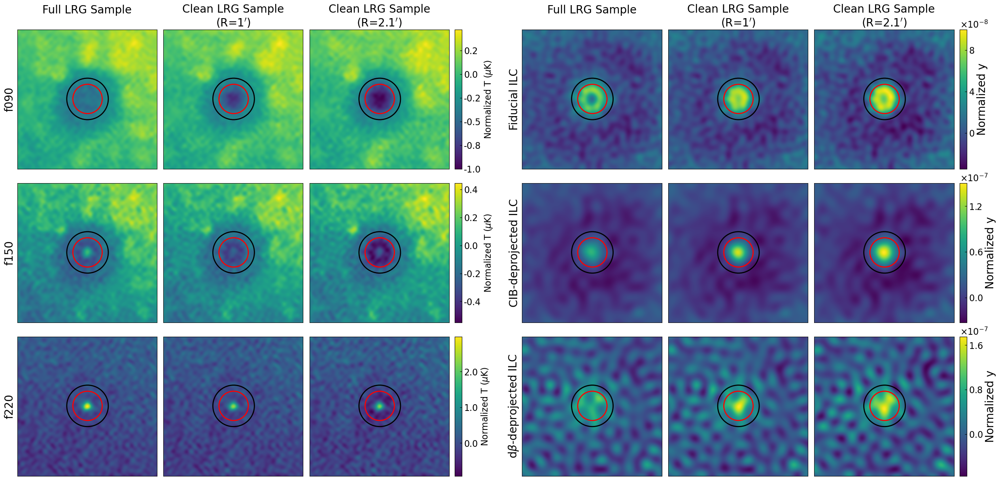

In [38]:
# LRG
sample = 'LRG'
stacks = lrg_stacks
ap = 2.1
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig = plt.figure(figsize=(27,13))

gs = fig.add_gridspec(
    3, 9,
    width_ratios=[1, 1, 1, 0.05, 0.35, 1, 1, 1, 0.05],
    left=0.08, right=0.97, bottom=0.08, top=0.95,
    wspace=0.05, hspace=0.1
)

# image axes
axs = np.empty((3, 9), dtype=object)
for r in range(3):
    for c in range(9):
        axs[r, c] = fig.add_subplot(gs[r, c])

for i, m in enumerate(['f090', 'f150', 'f220']):
    mins = []
    maxs = []
    for k in range(len(stacks[m])):
        mins.append(np.min(stacks[m][k]-np.mean(stacks[m][k])))
        maxs.append(np.max(stacks[m][k]-np.mean(stacks[m][k])))
    cbar_norm = Normalize(vmin=np.min(mins), vmax=np.max(maxs))
    images = []
    for j, stack in enumerate(stacks[m]):
        r_rad_submap = np.deg2rad(10/60.)
        pixel_size = (r_rad_submap*2/np.shape(stack)[0])*10800/np.pi
        ax = axs[i, j]
        im = ax.imshow(
            stack - np.mean(stack),
            origin='lower',
            norm=cbar_norm, cmap='viridis')
        images.append(im)
        disk = plt.Circle((np.shape(stack)[0]/2., np.shape(stack)[1]/2.), ap/pixel_size, color='red', fill=False, lw=2)
        disk2 = plt.Circle((np.shape(stack)[0]/2., np.shape(stack)[1]/2.), np.sqrt(2)*ap/pixel_size, color='black', fill=False, lw=2)
        ax.add_patch(disk)
        ax.add_patch(disk2)

    # colorbar axis (spans both rows)
    cax = fig.add_subplot(gs[i, 3])
    cbar = fig.colorbar(images[0], cax=cax)
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    cbar.ax.tick_params(labelsize=16)   # (or 7 at final scale)
    cbar.set_label(r'Normalized T ($\mu$K)', fontsize=16)
    for ax in axs[i, :]:
        ax.set_xticks([], [])
        ax.set_yticks([], [])

axs[0,0].set_ylabel('f090')
axs[1,0].set_ylabel('f150')
axs[2,0].set_ylabel('f220')
axs[0,0].set_title(f'Full {sample} Sample\n')
axs[0,1].set_title(f"Clean {sample} Sample\n" +r"(R=$1'$)")
axs[0,2].set_title(f"Clean {sample} Sample\n" +f"(R={ap}"+r"$'$)")

for i, m in enumerate(['ilc', 'ilc_cib', 'ilc_db']):
    mins = []
    maxs = []
    for k in range(len(stacks[m])):
        mins.append(np.min(stacks[m][k]-np.mean(stacks[m][k])))
        maxs.append(np.max(stacks[m][k]-np.mean(stacks[m][k])))
    cbar_norm = Normalize(vmin=np.min(mins), vmax=np.max(maxs))
    images = []
    for j, stack in enumerate(stacks[m]):
        r_rad_submap = np.deg2rad(10/60.)
        pixel_size = (r_rad_submap*2/np.shape(stack)[0])*10800/np.pi
        ax = axs[i, j+5]
        im = ax.imshow(
            stack - np.mean(stack),
            origin='lower',
            norm=cbar_norm, cmap='viridis')
        images.append(im)
        disk = plt.Circle((np.shape(stack)[0]/2., np.shape(stack)[1]/2.), ap/pixel_size, color='red', fill=False, lw=2)
        disk2 = plt.Circle((np.shape(stack)[0]/2., np.shape(stack)[1]/2.), np.sqrt(2)*ap/pixel_size, color='black', fill=False, lw=2)
        ax.add_patch(disk)
        ax.add_patch(disk2)

    # colorbar axis (spans both rows)
    cax = fig.add_subplot(gs[i, 8])
    cbar = fig.colorbar(images[0], cax=cax)
    cbar.ax.tick_params(labelsize=16)   # (or 7 at final scale)
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))  # always use scientific notation
    cbar.ax.yaxis.set_major_formatter(formatter)
    cbar.set_label(r'Normalized y', fontsize=20)
    cbar.ax.yaxis.set_major_locator(MaxNLocator(nbins=3, min_n_ticks=3, prune='upper'))
    offset_text = cbar.ax.yaxis.get_offset_text()
    offset_text.set_x(4)   # increase to move farther right
    offset_text.set_fontsize(16)
    for ax in axs[i, :]:
        ax.set_xticks([], [])
        ax.set_yticks([], [])
for ax in axs[:, 4]:
    fig.delaxes(ax) 
axs[0,5].set_ylabel('Fiducial ILC')
axs[1,5].set_ylabel('CIB-deprojected ILC')
axs[2,5].set_ylabel(r'd$\beta$-deprojected ILC')
axs[0,5].set_title(f'Full {sample} Sample\n')
axs[0,6].set_title(f"Clean {sample} Sample\n" +r"(R=$1'$)")
axs[0,7].set_title(f"Clean {sample} Sample\n" +f"(R={ap}"+r"$'$)")
plt.savefig(f'figures/Figure9_{sample}.pdf', bbox_inches='tight', pad_inches=0.1) 

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


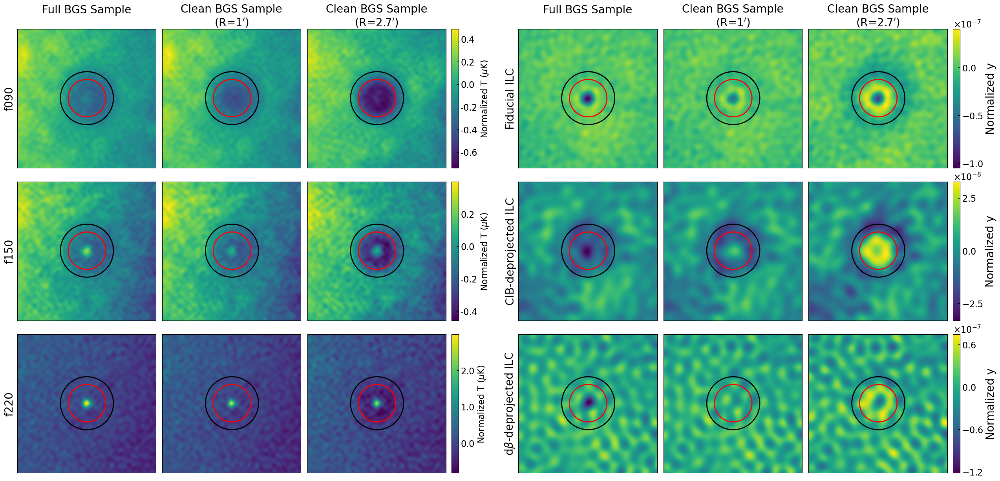

In [39]:
# BGS
sample = 'BGS'
stacks = bgs_stacks
ap = 2.7
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig = plt.figure(figsize=(27,13))

gs = fig.add_gridspec(
    3, 9,
    width_ratios=[1, 1, 1, 0.05, 0.35, 1, 1, 1, 0.05],
    left=0.08, right=0.97, bottom=0.08, top=0.95,
    wspace=0.05, hspace=0.1
)

# image axes
axs = np.empty((3, 9), dtype=object)
for r in range(3):
    for c in range(9):
        axs[r, c] = fig.add_subplot(gs[r, c])

for i, m in enumerate(['f090', 'f150', 'f220']):
    mins = []
    maxs = []
    for k in range(len(stacks[m])):
        mins.append(np.min(stacks[m][k]-np.mean(stacks[m][k])))
        maxs.append(np.max(stacks[m][k]-np.mean(stacks[m][k])))
    cbar_norm = Normalize(vmin=np.min(mins), vmax=np.max(maxs))
    images = []
    for j, stack in enumerate(stacks[m]):
        r_rad_submap = np.deg2rad(10/60.)
        pixel_size = (r_rad_submap*2/np.shape(stack)[0])*10800/np.pi
        ax = axs[i, j]
        im = ax.imshow(
            stack - np.mean(stack),
            origin='lower',
            norm=cbar_norm, cmap='viridis')
        images.append(im)
        disk = plt.Circle((np.shape(stack)[0]/2., np.shape(stack)[1]/2.), ap/pixel_size, color='red', fill=False, lw=2)
        disk2 = plt.Circle((np.shape(stack)[0]/2., np.shape(stack)[1]/2.), np.sqrt(2)*ap/pixel_size, color='black', fill=False, lw=2)
        ax.add_patch(disk)
        ax.add_patch(disk2)

    # colorbar axis (spans both rows)
    cax = fig.add_subplot(gs[i, 3])
    cbar = fig.colorbar(images[0], cax=cax)
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    cbar.ax.tick_params(labelsize=16)   # (or 7 at final scale)
    cbar.set_label(r'Normalized T ($\mu$K)', fontsize=16)
    for ax in axs[i, :]:
        ax.set_xticks([], [])
        ax.set_yticks([], [])

axs[0,0].set_ylabel('f090')
axs[1,0].set_ylabel('f150')
axs[2,0].set_ylabel('f220')
axs[0,0].set_title(f'Full {sample} Sample\n')
axs[0,1].set_title(f"Clean {sample} Sample\n" +r"(R=$1'$)")
axs[0,2].set_title(f"Clean {sample} Sample\n" +f"(R={ap}"+r"$'$)")

for i, m in enumerate(['ilc', 'ilc_cib', 'ilc_db']):
    mins = []
    maxs = []
    for k in range(len(stacks[m])):
        mins.append(np.min(stacks[m][k]-np.mean(stacks[m][k])))
        maxs.append(np.max(stacks[m][k]-np.mean(stacks[m][k])))
    cbar_norm = Normalize(vmin=np.min(mins), vmax=np.max(maxs))
    images = []
    for j, stack in enumerate(stacks[m]):
        r_rad_submap = np.deg2rad(10/60.)
        pixel_size = (r_rad_submap*2/np.shape(stack)[0])*10800/np.pi
        ax = axs[i, j+5]
        im = ax.imshow(
            stack - np.mean(stack),
            origin='lower',
            norm=cbar_norm, cmap='viridis')
        images.append(im)
        disk = plt.Circle((np.shape(stack)[0]/2., np.shape(stack)[1]/2.), ap/pixel_size, color='red', fill=False, lw=2)
        disk2 = plt.Circle((np.shape(stack)[0]/2., np.shape(stack)[1]/2.), np.sqrt(2)*ap/pixel_size, color='black', fill=False, lw=2)
        ax.add_patch(disk)
        ax.add_patch(disk2)

    # colorbar axis (spans both rows)
    cax = fig.add_subplot(gs[i, 8])
    cbar = fig.colorbar(images[0], cax=cax)
    cbar.ax.tick_params(labelsize=16)   # (or 7 at final scale)
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))  # always use scientific notation
    cbar.ax.yaxis.set_major_formatter(formatter)
    cbar.set_label(r'Normalized y', fontsize=20)
    cbar.ax.yaxis.set_major_locator(MaxNLocator(nbins=3, min_n_ticks=3, prune='upper'))
    offset_text = cbar.ax.yaxis.get_offset_text()
    offset_text.set_x(4)   # increase to move farther right
    offset_text.set_fontsize(16)
    for ax in axs[i, :]:
        ax.set_xticks([], [])
        ax.set_yticks([], [])
for ax in axs[:, 4]:
    fig.delaxes(ax) 
axs[0,5].set_ylabel('Fiducial ILC')
axs[1,5].set_ylabel('CIB-deprojected ILC')
axs[2,5].set_ylabel(r'd$\beta$-deprojected ILC')
axs[0,5].set_title(f'Full {sample} Sample\n')
axs[0,6].set_title(f"Clean {sample} Sample\n" +r"(R=$1'$)")
axs[0,7].set_title(f"Clean {sample} Sample\n" +f"(R={ap}"+r"$'$)")
plt.savefig(f'figures/Figure9_{sample}.pdf', bbox_inches='tight', pad_inches=0.1) 

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


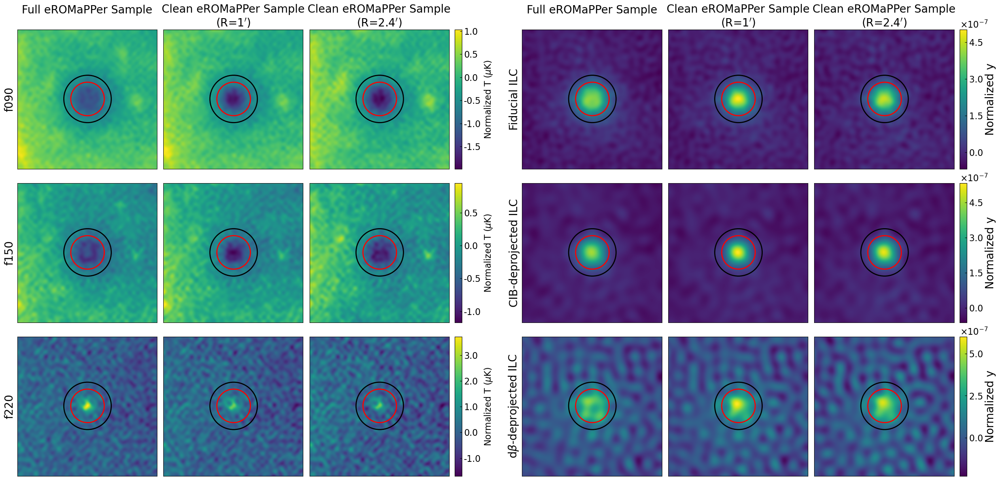

In [40]:
# optical
sample = 'eROMaPPer'
stacks = opt_stacks
ap = 2.4
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig = plt.figure(figsize=(27,13))

gs = fig.add_gridspec(
    3, 9,
    width_ratios=[1, 1, 1, 0.05, 0.35, 1, 1, 1, 0.05],
    left=0.08, right=0.97, bottom=0.08, top=0.95,
    wspace=0.05, hspace=0.1
)

# image axes
axs = np.empty((3, 9), dtype=object)
for r in range(3):
    for c in range(9):
        axs[r, c] = fig.add_subplot(gs[r, c])

for i, m in enumerate(['f090', 'f150', 'f220']):
    mins = []
    maxs = []
    for k in range(len(stacks[m])):
        mins.append(np.min(stacks[m][k]-np.mean(stacks[m][k])))
        maxs.append(np.max(stacks[m][k]-np.mean(stacks[m][k])))
    cbar_norm = Normalize(vmin=np.min(mins), vmax=np.max(maxs))
    images = []
    for j, stack in enumerate(stacks[m]):
        r_rad_submap = np.deg2rad(10/60.)
        pixel_size = (r_rad_submap*2/np.shape(stack)[0])*10800/np.pi
        ax = axs[i, j]
        im = ax.imshow(
            stack - np.mean(stack),
            origin='lower',
            norm=cbar_norm, cmap='viridis')
        images.append(im)
        disk = plt.Circle((np.shape(stack)[0]/2., np.shape(stack)[1]/2.), ap/pixel_size, color='red', fill=False, lw=2)
        disk2 = plt.Circle((np.shape(stack)[0]/2., np.shape(stack)[1]/2.), np.sqrt(2)*ap/pixel_size, color='black', fill=False, lw=2)
        ax.add_patch(disk)
        ax.add_patch(disk2)

    # colorbar axis (spans both rows)
    cax = fig.add_subplot(gs[i, 3])
    cbar = fig.colorbar(images[0], cax=cax)
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    cbar.ax.tick_params(labelsize=16)   # (or 7 at final scale)
    cbar.set_label(r'Normalized T ($\mu$K)', fontsize=16)
    for ax in axs[i, :]:
        ax.set_xticks([], [])
        ax.set_yticks([], [])

axs[0,0].set_ylabel('f090')
axs[1,0].set_ylabel('f150')
axs[2,0].set_ylabel('f220')
axs[0,0].set_title(f'Full {sample} Sample\n')
axs[0,1].set_title(f"Clean {sample} Sample\n" +r"(R=$1'$)")
axs[0,2].set_title(f"Clean {sample} Sample\n" +f"(R={ap}"+r"$'$)")

for i, m in enumerate(['ilc', 'ilc_cib', 'ilc_db']):
    mins = []
    maxs = []
    for k in range(len(stacks[m])):
        mins.append(np.min(stacks[m][k]-np.mean(stacks[m][k])))
        maxs.append(np.max(stacks[m][k]-np.mean(stacks[m][k])))
    cbar_norm = Normalize(vmin=np.min(mins), vmax=np.max(maxs))
    images = []
    for j, stack in enumerate(stacks[m]):
        r_rad_submap = np.deg2rad(10/60.)
        pixel_size = (r_rad_submap*2/np.shape(stack)[0])*10800/np.pi
        ax = axs[i, j+5]
        im = ax.imshow(
            stack - np.mean(stack),
            origin='lower',
            norm=cbar_norm, cmap='viridis')
        images.append(im)
        disk = plt.Circle((np.shape(stack)[0]/2., np.shape(stack)[1]/2.), ap/pixel_size, color='red', fill=False, lw=2)
        disk2 = plt.Circle((np.shape(stack)[0]/2., np.shape(stack)[1]/2.), np.sqrt(2)*ap/pixel_size, color='black', fill=False, lw=2)
        ax.add_patch(disk)
        ax.add_patch(disk2)

    # colorbar axis (spans both rows)
    cax = fig.add_subplot(gs[i, 8])
    cbar = fig.colorbar(images[0], cax=cax)
    cbar.ax.tick_params(labelsize=16)   # (or 7 at final scale)
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))  # always use scientific notation
    cbar.ax.yaxis.set_major_formatter(formatter)
    cbar.set_label(r'Normalized y', fontsize=20)
    cbar.ax.yaxis.set_major_locator(MaxNLocator(nbins=4, prune='upper'))
    offset_text = cbar.ax.yaxis.get_offset_text()
    offset_text.set_x(4)   # increase to move farther right
    offset_text.set_fontsize(16)
    for ax in axs[i, :]:
        ax.set_xticks([], [])
        ax.set_yticks([], [])
for ax in axs[:, 4]:
    fig.delaxes(ax) 
axs[0,5].set_ylabel('Fiducial ILC')
axs[1,5].set_ylabel('CIB-deprojected ILC')
axs[2,5].set_ylabel(r'd$\beta$-deprojected ILC')
axs[0,5].set_title(f'Full {sample} Sample\n')
axs[0,6].set_title(f"Clean {sample} Sample\n" +r"(R=$1'$)")
axs[0,7].set_title(f"Clean {sample} Sample\n" +f"(R={ap}"+r"$'$)")
plt.savefig(f'figures/Figure9_{sample}.pdf', bbox_inches='tight', pad_inches=0.1)
# plt.savefig(f'opt_compare_cleaned_ims.pdf', bbox_inches='tight', pad_inches=0.1) 

In [41]:
np.savez('figure_data/figure9_lrg.npz', lrg_f090=lrg_stacks['f090'], lrg_f150=lrg_stacks['f150'], lrg_f220=lrg_stacks['f220'], lrg_ilc=lrg_stacks['ilc'], lrg_ilc_cib=lrg_stacks['ilc_cib'], lrg_ilc_db=lrg_stacks['ilc_db'])
np.savez('figure_data/figure9_bgs.npz', bgs_f090=bgs_stacks['f090'], bgs_f150=bgs_stacks['f150'], bgs_f220=bgs_stacks['f220'], bgs_ilc=bgs_stacks['ilc'], bgs_ilc_cib=bgs_stacks['ilc_cib'], bgs_ilc_db=bgs_stacks['ilc_db'])
np.savez('figure_data/figure9_opt.npz', opt_f090=opt_stacks['f090'], opt_f150=opt_stacks['f150'], opt_f220=opt_stacks['f220'], opt_ilc=opt_stacks['ilc'], opt_ilc_cib=opt_stacks['ilc_cib'], opt_ilc_db=opt_stacks['ilc_db'])

# Figure 10

In [42]:
lrg_areas = np.pi*np.arange(0.6, 7.1, 0.5)**2
bgs_areas = np.pi*np.arange(0.7, 7.2, 0.5)**2
opt_areas = np.pi*np.arange(0.9, 7.4, 0.5)**2
lrg_profiles = {}
bgs_profiles = {}
opt_profiles = {}
for f in ['f090', 'f150', 'f220', 'ilc', 'ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']:
    lrg_profiles[f] = [pd.read_csv(f'profiles/{f}_lrg_L36_profiles.csv'), pd.read_csv(f'profiles/{f}_lrg_L36_radio_clean_profiles.csv')]
    bgs_profiles[f] = [pd.read_csv(f'profiles/{f}_bgs_M10_profiles.csv'), pd.read_csv(f'profiles/{f}_bgs_M10_radio_clean_profiles.csv')]
    opt_profiles[f] = [pd.read_csv(f'profiles/{f}_opt_L5_profiles.csv'), pd.read_csv(f'profiles/{f}_opt_L5_radio_clean_profiles.csv')]

In [43]:
profile_data = {}
profile_data['lrg'] = {}
profile_data['bgs'] = {}
profile_data['opt'] = {}
for f in ['f090', 'f150', 'ilc', 'ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']:
    profile_data['lrg'][f] = np.asarray([lrg_profiles[f][0]['radius'].values, lrg_profiles[f][0]['dy'].values, lrg_profiles[f][0]['dy_err'].values, lrg_profiles[f][1]['dy'].values, lrg_profiles[f][1]['dy_err'].values])
    profile_data['bgs'][f] = np.asarray([bgs_profiles[f][0]['radius'].values, bgs_profiles[f][0]['dy'].values, bgs_profiles[f][0]['dy_err'].values, bgs_profiles[f][1]['dy'].values, bgs_profiles[f][1]['dy_err'].values])
    profile_data['opt'][f] = np.asarray([opt_profiles[f][0]['radius'].values, opt_profiles[f][0]['dy'].values, opt_profiles[f][0]['dy_err'].values, opt_profiles[f][1]['dy'].values, opt_profiles[f][1]['dy_err'].values])
profile_data['lrg']['f220'] = np.asarray([lrg_profiles['f220'][0]['radius'].values, lrg_profiles['f220'][0]['dT'].values, lrg_profiles['f220'][0]['dT_err'].values, lrg_profiles['f220'][1]['dT'].values, lrg_profiles['f220'][1]['dT_err'].values])
profile_data['bgs']['f220'] = np.asarray([bgs_profiles['f220'][0]['radius'].values, bgs_profiles['f220'][0]['dT'].values, bgs_profiles['f220'][0]['dT_err'].values, bgs_profiles['f220'][1]['dT'].values, bgs_profiles['f220'][1]['dT_err'].values])
profile_data['opt']['f220'] = np.asarray([opt_profiles['f220'][0]['radius'].values, opt_profiles['f220'][0]['dT'].values, opt_profiles['f220'][0]['dT_err'].values, opt_profiles['f220'][1]['dT'].values, opt_profiles['f220'][1]['dT_err'].values])

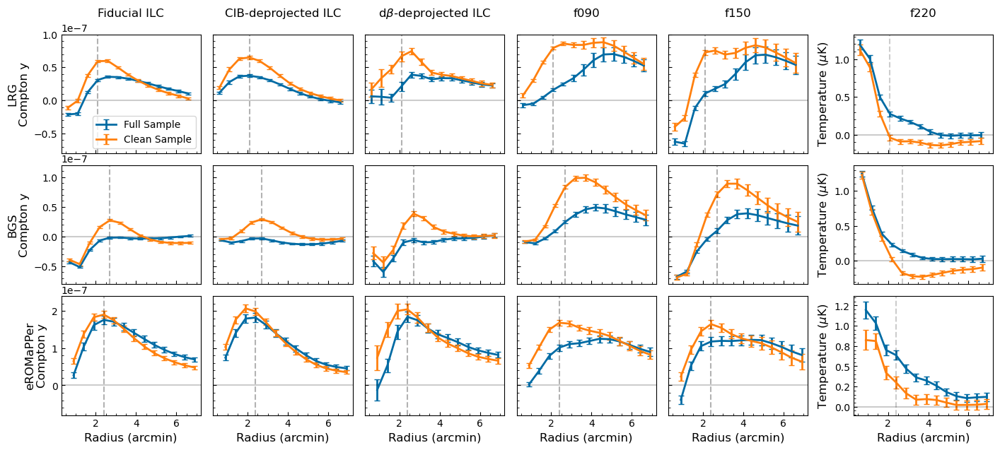

In [44]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
labels = ['LRG\n', 'BGS\n', 'eROMaPPer\n']
fig = plt.figure(figsize=(17, 7))
gs = gridspec.GridSpec(
    3, 7,
    figure=fig,
    width_ratios=[1, 1, 1, 1, 1, 0.15, 1],
    wspace=0.1,
    hspace=0.1)
axs = np.empty((3, 6), dtype=object)

for i in range(3):
    for j in range(5):
        axs[i, j] = fig.add_subplot(
            gs[i, j],
            sharex=axs[0, 0] if (i > 0 or j > 0) else None)
    axs[i, 5] = fig.add_subplot(
        gs[i, 6],
        sharex=axs[0, 5] if i > 0 else None)

aps = [2.1, 2.7, 2.4]
for i, m in enumerate(['lrg', 'bgs', 'opt']):
    for j, k in enumerate(['ilc', 'ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7', 'f090', 'f150']):
        axs[i, j].errorbar(profile_data[m][k][0], profile_data[m][k][1], yerr=profile_data[m][k][2], label='Full Sample', lw=2, capsize=3)
        axs[i, j].errorbar(profile_data[m][k][0], profile_data[m][k][3], yerr=profile_data[m][k][4], label="Clean Sample", lw=2, capsize=3)
        axs[i, j].axvline(aps[i], ls='--', color='black', alpha=0.3)
    axs[i, -1].errorbar(profile_data[m]['f220'][0], profile_data[m]['f220'][1], yerr=profile_data[m]['f220'][2], label='Full Sample', lw=2, capsize=3)
    axs[i, -1].errorbar(profile_data[m]['f220'][0], profile_data[m]['f220'][3], yerr=profile_data[m]['f220'][4], label="Clean Sample", lw=2, capsize=3)
    axs[i, -1].axvline(aps[i], ls='--', color='black', alpha=0.2)

axs[0,3].set_title('f090', y=1.1)
axs[0,4].set_title('f150', y=1.1)
axs[0,5].set_title('f220', y=1.1)
axs[0,0].set_title('Fiducial ILC', y=1.1)
axs[0,1].set_title('CIB-deprojected ILC', y=1.1)
axs[0,2].set_title(r'd$\beta$-deprojected ILC', y=1.1)

for j in range(len(labels)):
    axs[j, 0].set_ylabel(labels[j]+'Compton y')
for j in range(len(labels)):
    axs[j, -1].set_ylabel('Temperature ($\mu$K)')
for ax in axs[2, :]:
    ax.set_xlabel('Radius (arcmin)')
for ax in axs.flatten():
    ax.axhline(0, color='black', alpha=0.2)
    ax.minorticks_on()
# plt.tight_layout()
for ax in axs[0, 0:-1]:
    ax.set_ylim(-0.8e-7, 1e-7)
for ax in axs[1, 0:-1]:
    ax.set_ylim(-0.8e-7, 1.2e-7)
for ax in axs[2, 0:-1]:
    ax.set_ylim(-0.8e-7, 2.4e-7)
for ax in axs[:, 1:-1].flatten():
    plt.setp(ax.get_yticklabels(), visible=False)
    ax.yaxis.get_offset_text().set_visible(False)
for ax in axs[0:-1, :].flatten():
    plt.setp(ax.get_xticklabels(), visible=False)
axs[0,0].legend(fontsize=10, loc='lower right')

for ax in axs[:, -1]:
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
plt.savefig('figures/Figure10.pdf', bbox_inches='tight', pad_inches=0.1)
# plt.savefig('allsamples_yprofiles_allmaps_compare_radio_ukandy.pdf', bbox_inches='tight', pad_inches=0.1)

In [45]:
np.savez('figure_data/figure10_lrg.npz', lrg_f090=profile_data['lrg']['f090'], lrg_f150=profile_data['lrg']['f150'], lrg_f220=profile_data['lrg']['f220'], lrg_ilc=profile_data['lrg']['ilc'], lrg_ilc_cib=profile_data['lrg']['ilc_cib_1.6_10.7'], lrg_ilc_db=profile_data['lrg']['ilc_db_1.6_10.7'])
np.savez('figure_data/figure10_bgs.npz', bgs_f090=profile_data['bgs']['f090'], bgs_f150=profile_data['bgs']['f150'], bgs_f220=profile_data['bgs']['f220'], bgs_ilc=profile_data['bgs']['ilc'], bgs_ilc_cib=profile_data['bgs']['ilc_cib_1.6_10.7'], bgs_ilc_db=profile_data['bgs']['ilc_db_1.6_10.7'])
np.savez('figure_data/figure10_opt.npz', opt_f090=profile_data['opt']['f090'], opt_f150=profile_data['opt']['f150'], opt_f220=profile_data['opt']['f220'], opt_ilc=profile_data['opt']['ilc'], opt_ilc_cib=profile_data['opt']['ilc_cib_1.6_10.7'], opt_ilc_db=profile_data['opt']['ilc_db_1.6_10.7'])

# Figure 11

In [46]:
opt_profiles = {}
for f in ['f090', 'f150']:
    opt_profiles[f] = [pd.read_csv(f'profiles/{f}_opt_L5_radio_clean_profile_deproj.csv'), pd.read_csv(f'profiles/{f}_opt_L10_radio_clean_profile_deproj.csv')]

In [47]:
bins = ['L5', 'L10']
profile_data = {}
for f in ['f090', 'f150']:
    profile_data[f] = {}
    for i, b in enumerate(bins):
        profile_data[f][b] = np.asarray([opt_profiles[f][i]['radius'].values, opt_profiles[f][i]['dy_deproj'].values, opt_profiles[f][i]['dy_deproj_err'].values, opt_profiles[f][i]['dy_bc'].values])

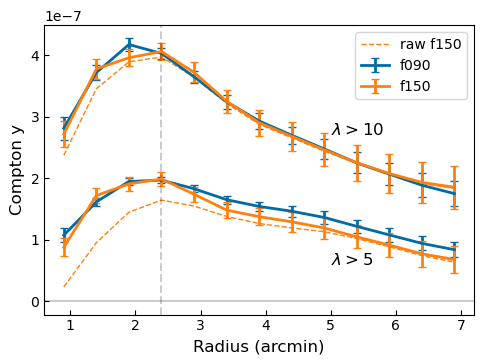

In [48]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
labels = ['f090', 'f150']
names = [r'$\lambda > 5$', r'$\lambda > 10$']
plt.figure(figsize=[5, 3.8])
for i, lum in enumerate(['L5', 'L10']):
    for j, k in enumerate(['f090', 'f150']):
        if i == 0:
            plt.errorbar(profile_data[k][lum][0], profile_data[k][lum][1], yerr=profile_data[k][lum][2], label=labels[j], color=colors[j], lw=2, capsize=3)
            if j == 1:
                plt.plot(profile_data[k][lum][0], profile_data[k][lum][3], label='raw f150', color=colors[1], lw=1, ls='dashed')
        else:
            plt.errorbar(profile_data[k][lum][0], profile_data[k][lum][1], yerr=profile_data[k][lum][2], color=colors[j], lw=2, capsize=3)
            if j == 1:
                plt.plot(profile_data[k][lum][0], profile_data[k][lum][3], color=colors[1], lw=1, ls='dashed')

plt.axvline(2.4, ls='--', color='black', alpha=0.2)
plt.text(5, 0.6e-7, names[0])
plt.text(5, 2.7e-7, names[1])

plt.ylabel('Compton y')
plt.xlabel('Radius (arcmin)')
plt.axhline(0, color='black', alpha=0.2)
plt.tight_layout()

plt.legend()
plt.savefig('figures/Figure11.pdf', bbox_inches='tight', pad_inches=0.1)

In [49]:
np.savez('figure_data/figure11.npz', f090_l5=profile_data['f090']['L5'], f090_l10=profile_data['f090']['L10'], f150_l5=profile_data['f150']['L5'], f150_l10=profile_data['f150']['L10'])

# Figure 12

For the LRG and BGS samples (full samples), all single-frequency measurements are deprojected.
For the LRG and BGS samples (radio-clean samples), all single-frequency measurements are *not* deprojected (because f220 is not everywhere positive).

For the optically-selected samples, we are able to deproject the single-frequency measurements for the L5 and L10 radio-clean bins. We are also able to deproject some of the disjoint bins, but those come into play later in the paper.

1. L5D (full-sample)
2. L5, L10, L5D, L10D (radio-clean)



In [61]:
lrg_bins =['L36', 'L48', 'L60', 'L79', 'L98', 'L36D', 'L48D', 'L60D', 'L79D']
bgs_bins = ['M10', 'M10.25', 'M10.5', 'M10.75', 'M11', 'M11.25']
opt_bins = ['L5', 'L10', 'L20']
yaps = pd.DataFrame()
aps = [2.1, 2.7, 2.4]
for f in ['f090', 'f150']:
    for lum in lrg_bins:
        profiles = pd.read_csv(f'profiles/{f}_lrg_{lum}_profile_deproj.csv')
        yaps.loc[lum,f'{f}_dy'] = profiles[np.round(profiles['radius'], 1)==aps[0]]['dy_deproj'].values[0]
        yaps.loc[lum,f'{f}_dy_err'] = profiles[np.round(profiles['radius'], 1)==aps[0]]['dy_deproj_err'].values[0]
        profiles_rc = pd.read_csv(f'profiles/{f}_lrg_{lum}_radio_clean_profile_deproj.csv')
        yaps.loc[lum+'_rc',f'{f}_dy'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[0]]['dy_bc'].values[0]
        yaps.loc[lum+'_rc',f'{f}_dy_err'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[0]]['dy_err_bc'].values[0]
    for lum in bgs_bins:
        profiles = pd.read_csv(f'profiles/{f}_bgs_{lum}_profile_deproj.csv')
        yaps.loc[lum,f'{f}_dy'] = profiles[np.round(profiles['radius'], 1)==aps[1]]['dy_deproj'].values[0]
        yaps.loc[lum,f'{f}_dy_err'] = profiles[np.round(profiles['radius'], 1)==aps[1]]['dy_deproj_err'].values[0]
        profiles_rc = pd.read_csv(f'profiles/{f}_bgs_{lum}_radio_clean_profile_deproj.csv')
        yaps.loc[lum+'_rc',f'{f}_dy'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[1]]['dy_bc'].values[0]
        yaps.loc[lum+'_rc',f'{f}_dy_err'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[1]]['dy_err_bc'].values[0]
    for lum in opt_bins:
        profiles = pd.read_csv(f'profiles/{f}_opt_{lum}_profile_deproj.csv')
        profiles_rc = pd.read_csv(f'profiles/{f}_opt_{lum}_radio_clean_profile_deproj.csv')
        if lum in ['L5', 'L10']: # only radio clean deprojected
            yaps.loc[lum,f'{f}_dy'] = profiles[np.round(profiles['radius'], 1)==aps[2]]['dy_bc'].values[0]
            yaps.loc[lum,f'{f}_dy_err'] = profiles[np.round(profiles['radius'], 1)==aps[2]]['dy_err_bc'].values[0]
            yaps.loc[lum+'_rc',f'{f}_dy'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[2]]['dy_deproj'].values[0]
            yaps.loc[lum+'_rc',f'{f}_dy_err'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[2]]['dy_deproj_err'].values[0]
        else: # none deprojected
            yaps.loc[lum,f'{f}_dy'] = profiles[np.round(profiles['radius'], 1)==aps[2]]['dy_bc'].values[0]
            yaps.loc[lum,f'{f}_dy_err'] = profiles[np.round(profiles['radius'], 1)==aps[2]]['dy_err_bc'].values[0]
            yaps.loc[lum+'_rc',f'{f}_dy'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[2]]['dy_bc'].values[0]
            yaps.loc[lum+'_rc',f'{f}_dy_err'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[2]]['dy_err_bc'].values[0]
for f in ['ilc', 'ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']:
    for lum in lrg_bins:
        profiles = pd.read_csv(f'profiles/{f}_lrg_{lum}_profiles.csv')
        yaps.loc[lum,f'{f}_dy'] = profiles[np.round(profiles['radius'], 1)==aps[0]]['dy_bc'].values[0]
        yaps.loc[lum,f'{f}_dy_err'] = profiles[np.round(profiles['radius'], 1)==aps[0]]['dy_err_bc'].values[0]
        profiles_rc = pd.read_csv(f'profiles/{f}_lrg_{lum}_radio_clean_profiles.csv')
        yaps.loc[lum+'_rc',f'{f}_dy'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[0]]['dy_bc'].values[0]
        yaps.loc[lum+'_rc',f'{f}_dy_err'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[0]]['dy_err_bc'].values[0]
    for lum in bgs_bins:
        profiles = pd.read_csv(f'profiles/{f}_bgs_{lum}_profiles.csv')
        yaps.loc[lum,f'{f}_dy'] = profiles[np.round(profiles['radius'], 1)==aps[1]]['dy_bc'].values[0]
        yaps.loc[lum,f'{f}_dy_err'] = profiles[np.round(profiles['radius'], 1)==aps[1]]['dy_err_bc'].values[0]
        profiles_rc = pd.read_csv(f'profiles/{f}_bgs_{lum}_radio_clean_profiles.csv')
        yaps.loc[lum+'_rc',f'{f}_dy'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[1]]['dy_bc'].values[0]
        yaps.loc[lum+'_rc',f'{f}_dy_err'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[1]]['dy_err_bc'].values[0]
    for lum in opt_bins:
        profiles = pd.read_csv(f'profiles/{f}_opt_{lum}_profiles.csv')
        yaps.loc[lum,f'{f}_dy'] = profiles[np.round(profiles['radius'], 1)==aps[2]]['dy_bc'].values[0]
        yaps.loc[lum,f'{f}_dy_err'] = profiles[np.round(profiles['radius'], 1)==aps[2]]['dy_err_bc'].values[0]
        profiles_rc = pd.read_csv(f'profiles/{f}_opt_{lum}_radio_clean_profiles.csv')
        yaps.loc[lum+'_rc',f'{f}_dy'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[2]]['dy_bc'].values[0]
        yaps.loc[lum+'_rc',f'{f}_dy_err'] = profiles_rc[np.round(profiles_rc['radius'], 1)==aps[2]]['dy_err_bc'].values[0]

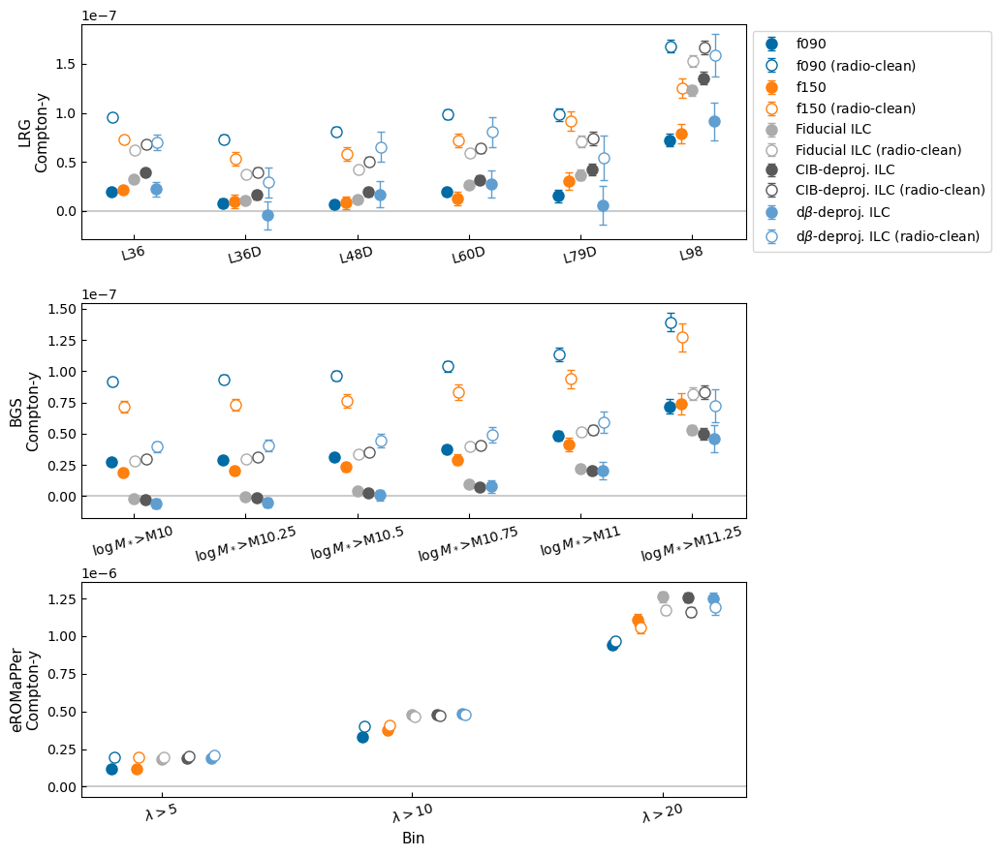

In [62]:
# APJ-style font tuning
plt.rcParams.update({
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

labels = [r'$\mathrm{f090}$',
    r'$\mathrm{f150}$',
          'Fiducial ILC',
    'CIB-deproj. ILC',
          r'd$\beta$-deproj. ILC']

ms = ['f090', 'f150', 'ilc', 'ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']
lrg_bins = ['L36', 'L36D', 'L48D', 'L60D', 'L79D', 'L98']
bgs_bins = ['M10', 'M10.25', 'M10.5', 'M10.75', 'M11', 'M11.25']
opt_bins = ['L5', 'L10', 'L20']
aps = [2.1, 2.7, 2.4]

fig, axs = plt.subplots(3, 1, figsize=[8, 9], sharex=False, sharey=False)
# labs = ['', ' (clean)']
mfcs = [None, 'white']

for i, lum in enumerate(lrg_bins):
    for j, k in enumerate(ms):
        axs[0].errorbar(i+(j*0.1), yaps.loc[lum, f'{k}_dy'], yerr=yaps.loc[lum, f'{k}_dy_err'], label=labels[j], color=colors[j], mfc=mfcs[0], **errbar_kwargs)
        axs[0].errorbar(i+(j*0.1)+0.01, yaps.loc[lum+'_rc', f'{k}_dy'], yerr=yaps.loc[lum+'_rc', f'{k}_dy_err'], label=labels[j]+' (radio-clean)', color=colors[j], mfc=mfcs[1], **errbar_kwargs)
axs[0].set_ylabel('LRG\nCompton-y')
axs[0].set_xticks(np.arange(len(lrg_bins))+0.2, lrg_bins, rotation=15)

for i, lum in enumerate(bgs_bins):
    for j, k in enumerate(ms):
        axs[1].errorbar(i+(j*0.1), yaps.loc[lum, f'{k}_dy'], yerr=yaps.loc[lum, f'{k}_dy_err'], label=labels[j], color=colors[j], mfc=mfcs[0], **errbar_kwargs)
        axs[1].errorbar(i+(j*0.1)+0.01, yaps.loc[lum+'_rc', f'{k}_dy'], yerr=yaps.loc[lum+'_rc', f'{k}_dy_err'], label=labels[j]+' (radio-clean)', color=colors[j], mfc=mfcs[1], **errbar_kwargs)
axs[1].set_ylabel('BGS\nCompton-y')
axs[1].set_xticks(np.arange(len(bgs_bins))+0.2, [r'$\log M_*$'+f'>{l}' for l in bgs_bins], rotation=15)

for i, lum in enumerate(opt_bins):
    for j, k in enumerate(ms):
        axs[2].errorbar(i+(j*0.1), yaps.loc[lum, f'{k}_dy'], yerr=yaps.loc[lum, f'{k}_dy_err'], label=labels[j], color=colors[j], mfc=mfcs[0], **errbar_kwargs)
        axs[2].errorbar(i+(j*0.1)+0.01, yaps.loc[lum+'_rc', f'{k}_dy'], yerr=yaps.loc[lum+'_rc', f'{k}_dy_err'], label=labels[j]+' (radio-clean)', color=colors[j], mfc=mfcs[1], **errbar_kwargs)
axs[2].set_ylabel('eROMaPPer\nCompton-y')
axs[2].set_xticks(np.arange(len(opt_bins))+0.2, [r'$\lambda>5$', r'$\lambda>10$', r'$\lambda>20$'], rotation=15)
axs[2].set_xlabel('Bin')
for ax in axs.flatten():
    ax.axhline(0, color='black', alpha=0.2)
plt.tight_layout()
handles, labels = axs[0].get_legend_handles_labels()
axs[0].legend(handles=handles[0:10], labels=labels[0:10], bbox_to_anchor=[1,1])
plt.subplots_adjust(hspace=0.3)
plt.savefig('figures/Figure12.pdf', bbox_inches='tight', pad_inches=0.1)
# plt.savefig('/hpc/group/cosmology/jem189/scratch/plots/paper_plots_20260520/allsamples_final_yaps_wradio.pdf', bbox_inches='tight', pad_inches=0.1)

In [63]:
yaps.to_csv('figure_data/figure12.csv')

# Figure 13

See the `ytau.ipynb` notebook for the analysis for Figures 13-17

In [22]:
figdata = pd.read_csv('figure_data/figure13.csv', index_col=0)
figdata

,f150_y,f150_y_err,f150_tau,f150_tau_err,ilc_cib_1.6_10.7_y,ilc_cib_1.6_10.7_y_err,ilc_cib_1.6_10.7_tau,ilc_cib_1.6_10.7_tau_err,ilc_db_1.6_10.7_y,ilc_db_1.6_10.7_y_err,ilc_db_1.6_10.7_tau,ilc_db_1.6_10.7_tau_err
L36D,9.785550e-09,6.852893e-09,0.000036,0.000012,1.556342e-08,3.886953e-09,0.000027,0.000011,-4.120209e-09,1.356518e-08,0.000027,0.000011
L36D_rc,5.320026e-08,6.779528e-09,0.000036,0.000012,3.799162e-08,4.381249e-09,0.000027,0.000011,2.780765e-08,1.493061e-08,0.000027,0.000011
L48D,8.309208e-09,6.437606e-09,0.000043,0.000011,1.848212e-08,3.988527e-09,0.000041,0.000010,1.641918e-08,1.289746e-08,0.000041,0.000010
L48D_rc,5.835027e-08,6.944222e-09,0.000043,0.000011,4.820201e-08,4.358361e-09,0.000041,0.000010,6.268732e-08,1.451893e-08,0.000041,0.000010
L60D,1.312601e-08,6.900325e-09,0.000025,0.000011,3.058441e-08,3.962955e-09,0.000044,0.000010,2.625767e-08,1.317212e-08,0.000044,0.000010
L60D_rc,7.209425e-08,6.817951e-09,0.000025,0.000011,6.104445e-08,4.381985e-09,0.000044,0.000010,7.696467e-08,1.497853e-08,0.000044,0.000010
L79D,3.029740e-08,8.940357e-09,0.000034,0.000018,4.033214e-08,5.673671e-09,0.000046,0.000017,5.416599e-09,1.864925e-08,0.000046,0.000017
L79D_rc,9.192086e-08,9.719182e-09,0.000034,0.000018,7.033687e-08,6.526818e-09,0.000046,0.000017,5.170585e-08,2.167454e-08,0.000046,0.000017


In [23]:
model = np.load('figure_data/figure13_model.npz')

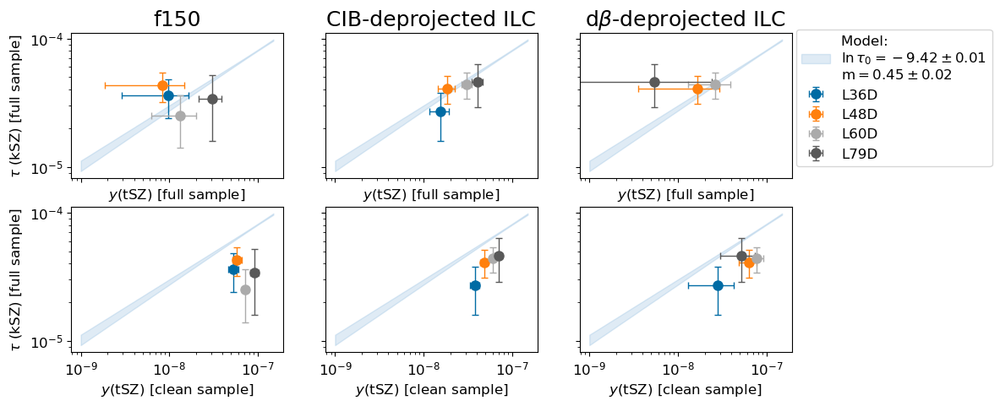

In [24]:
# plot y-tau (Figure 13)
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 12,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

fig, axs = plt.subplots(2, 3, figsize=(11, 6), sharex=True, sharey=True)
lums = ['L36D', 'L48D', 'L60D', 'L79D']
labels = ['f150', 'CIB-deprojected ILC', r'd$\beta$-deprojected ILC']
inds = ['', '_rc']
for i, m in enumerate(['f150', 'ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']):
    axs[0, i].set_title(labels[i])
    for lum in lums:
        ydata = figdata.loc[lum, m+'_tau']
        yerr = figdata.loc[lum, m+'_tau_err']
        for j, ind in enumerate(inds):
            xdata = figdata.loc[lum+ind, m+'_y']
            xerr = figdata.loc[lum+ind, m+'_y_err']
            
            # skip negative values
            mask = np.array(xdata) >= 0
            xdata_plot = np.array(xdata)[mask]
            ydata_plot = np.array(ydata)[mask]
            xerr_plot = np.array(xerr)[mask] if xerr is not None else None
            yerr_plot = np.array(yerr)[mask] if yerr is not None else None
            axs[j, i].errorbar(xdata_plot, ydata_plot, xerr=xerr_plot, yerr=yerr_plot, label=lum, **errbar_kwargs)

for ax in axs.flatten():
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(axis='both', which='major', labelsize=12)        
    ax.fill_between(
        model['y_model'], 
        y1=(model['tau_model'] - model['tau_err_model']), 
        y2=(model['tau_model'] + model['tau_err_model']), 
        color=colors[4], alpha=0.2,
        label='Model: \n'+r'$\ln\tau_0=-9.42 \pm 0.01$'+'\n'+r'm$=0.45\pm0.02$')

for ax in axs[0, :]:
        ax.set_xlabel(r'$y (\mathrm{tSZ})$ [full sample]')
for ax in axs[1, :]:
        ax.set_xlabel(r'$y (\mathrm{tSZ})$ [clean sample]')
for ax in axs[:, 0]:
    ax.set_ylabel(r'$\tau\ (\mathrm{kSZ})$ [full sample]')
handles, labels_legend = axs[0,0].get_legend_handles_labels()
fig.legend(handles, labels_legend, loc='upper center', fontsize=12, bbox_to_anchor=(1.01, 0.9), frameon=True)
plt.subplots_adjust(bottom=0.25)
plt.savefig('figures/Figure13.pdf', bbox_inches='tight', pad_inches=0.1)

# Figure 14

In [25]:
figdata = pd.read_csv('figure_data/figure14.csv', index_col=0)
figdata

,ilc_cib_1.6_10.7_y,ilc_cib_1.6_10.7_y_err,ilc_cib_1.6_10.7_tau,ilc_cib_1.6_10.7_tau_err,ilc_db_1.6_10.7_y,ilc_db_1.6_10.7_y_err,ilc_db_1.6_10.7_tau,ilc_db_1.6_10.7_tau_err
M10,-3.013464e-09,1.500822e-09,0.000012,0.000006,-5.659566e-09,3.524504e-09,0.000012,0.000006
M10_rc,2.911492e-08,1.874098e-09,0.000012,0.000006,3.876462e-08,4.251483e-09,0.000012,0.000006
M10.25,-1.406290e-09,1.617095e-09,0.000022,0.000007,-4.895765e-09,3.722390e-09,0.000022,0.000007
M10.25_rc,3.062678e-08,2.004943e-09,0.000022,0.000007,3.939474e-08,4.469003e-09,0.000022,0.000007
M10.5,2.275061e-09,1.824277e-09,0.000022,0.000008,7.802731e-10,4.207334e-09,0.000022,0.000008
M10.5_rc,3.478209e-08,2.252304e-09,0.000022,0.000008,4.360680e-08,5.246672e-09,0.000022,0.000008
M10.75,6.885631e-09,2.248992e-09,0.000033,0.000009,7.574554e-09,5.190472e-09,0.000033,0.000009
M10.75_rc,3.965188e-08,2.724730e-09,0.000033,0.000009,4.796520e-08,6.172465e-09,0.000033,0.000009
M11,1.983780e-08,2.856890e-09,0.000054,0.000011,2.023975e-08,6.835432e-09,0.000054,0.000011
M11_rc,5.180243e-08,3.586327e-09,0.000054,0.000011,5.804931e-08,8.333849e-09,0.000054,0.000011


In [26]:
model = np.load('figure_data/figure14_model.npz')

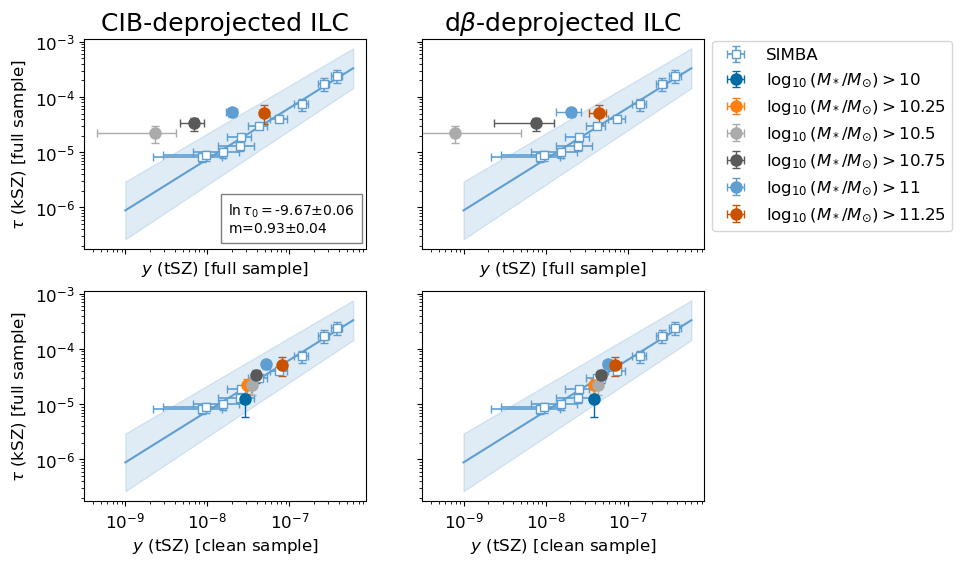

In [27]:
# --- Fonts / style ---
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 12,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

fig, axs = plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=True)

labels = ['CIB-deprojected ILC', r'd$\beta$-deprojected ILC']
ms = ['ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']
inds = ['', '_rc']
lums = ['M10', 'M10.25', 'M10.5', 'M10.75', 'M11', 'M11.25']

# plot the model
for ax in axs.flatten():
    ax.errorbar(model['simba_y'], model['simba_tau'], xerr=model['simba_y_err'], yerr=model['simba_tau_err'], color=colors[4], marker='s', lw=0, elinewidth=1.2, capsize=3, mfc='white', label='SIMBA')
    ax.plot(model['y_model'], model['taufit'], color=colors[4])
    ax.fill_between(model['y_model'], model['t_low'], model['t_high'], alpha=0.2, color=colors[4])

# plot the data points
for i, m in enumerate(ms):
    axs[0, i].set_title(labels[i])
    for lum in lums:
        ydata = figdata.loc[lum, m+'_tau']
        yerr = figdata.loc[lum, m+'_tau_err']
        for j, ind in enumerate(inds):
            xdata = figdata.loc[lum+ind, m+'_y']
            xerr = figdata.loc[lum+ind, m+'_y_err']
            
            # skip negative values
            mask = np.array(xdata) >= 0
            xdata_plot = np.array(xdata)[mask]
            ydata_plot = np.array(ydata)[mask]
            xerr_plot = np.array(xerr)[mask] if xerr is not None else None
            yerr_plot = np.array(yerr)[mask] if yerr is not None else None
            axs[j, i].errorbar(xdata_plot, ydata_plot, xerr=xerr_plot, yerr=yerr_plot, label=r'$\log_{10}(M_*/M_{\odot}) >$' +f'{lum[1:]}', **errbar_kwargs)

for ax in axs.flatten():
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(axis='both', which='major', labelsize=12)

popt = model['popt']
stds = model['stds']

axs[0,0].text(1.8e-8, 3.5e-7, r'$\ln\tau_0=$'+f'{popt[0]:.2f}'+r'$\pm$'+f'{stds[0]:.2f}'+'\n'+f'm={popt[1]:.2f}'+r'$\pm$'+f'{stds[1]:.2f}', fontsize=10,bbox={'facecolor': 'white', 'alpha': 0.5, 'pad': 5})

for ax in axs[:, 0]:
    ax.set_ylabel(r'$\tau\ (\mathrm{kSZ})$ [full sample]')

handles, labels_legend = axs[1, 1].get_legend_handles_labels()

for ax in axs[0, :]:
    ax.set_xlabel(r'$y\ (\mathrm{tSZ})$ [full sample]')

for ax in axs[1, :]:
    ax.set_xlabel(r'$y\ (\mathrm{tSZ})$ [clean sample]')

fig.legend(handles, labels_legend,loc='upper center', fontsize=12, bbox_to_anchor=(1.06, 0.89), frameon=True)
plt.savefig('figures/Figure14.pdf', bbox_inches='tight', pad_inches=0.1)

# Figure 15

In [28]:
figdata = pd.read_csv('figure_data/figure15.csv', index_col=0)
figdata

,ilc_db_1.6_10.7_y,ilc_db_1.6_10.7_y_err,ilc_db_1.6_10.7_tau,ilc_db_1.6_10.7_tau_err
L5,1.843102e-07,1.446933e-08,0.000063,0.000010
L10,4.687588e-07,2.326193e-08,0.000125,0.000022
L20,1.207499e-06,4.117579e-08,0.000213,0.000065


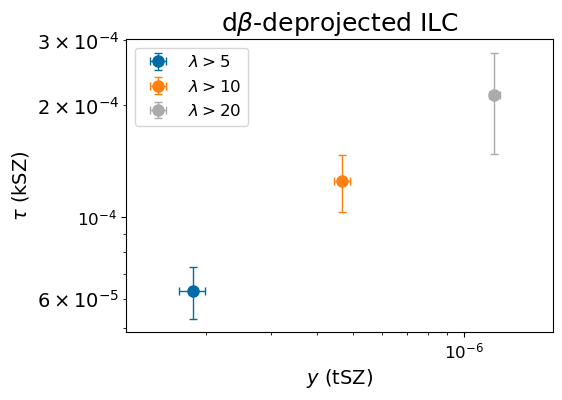

In [29]:
plt.figure(figsize=[5.5,3.8])

label = r'd$\beta$-deprojected ILC'
mkey = 'ilc_db_1.6_10.7'
plotlabels = [r'$\lambda >5$', r'$\lambda > 10$', r'$\lambda > 20$']

labs = ['L5', 'L10', 'L20']
plt.title(label)
figure_data = pd.DataFrame()
for j, lum in enumerate(labs):
    xdata = figdata.loc[lum, m+'_y']
    xerr = figdata.loc[lum, m+'_y_err']
    ydata = figdata.loc[lum, m+'_tau']
    yerr = figdata.loc[lum, m+'_tau_err']
    
    plt.errorbar(xdata, ydata, xerr=xerr, yerr=yerr,label=plotlabels[j], **errbar_kwargs)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$y\ (\mathrm{tSZ})$', fontsize=14)
plt.gca().tick_params(axis='both', which='major', labelsize=12)
plt.gca().set_aspect(aspect='equal', adjustable='datalim')  # make square
plt.ylabel(r'$\tau \ (\mathrm{kSZ})$', fontsize=14)
plt.legend(loc='upper left', fontsize=12, frameon=True)
plt.savefig('figures/Figure15.pdf', bbox_inches='tight')

# Figure 16

In [47]:
figdata = pd.read_csv('figure_data/figure16.csv', index_col=0)
samps = ['full_sample', 'radio_clean']
model = {}
for samp in samps:
    model[samp] = np.load(f'figure_data/figure16_model_{samp}.npz')
figdata

,ilc_db_1.6_10.7_y,ilc_db_1.6_10.7_y_err,ilc_db_1.6_10.7_tau,ilc_db_1.6_10.7_tau_err
L5D,2.115252e-08,1.194689e-08,0.000034,0.000012
L10D,1.850921e-07,1.957404e-08,0.000081,0.000021
L20,1.207499e-06,4.117579e-08,0.000213,0.000065
L5D_rc,7.231309e-08,1.424378e-08,0.000034,0.000012
L10D_rc,2.458271e-07,2.340459e-08,0.000081,0.000021
L20_rc,1.153083e-06,4.796398e-08,0.000213,0.000065


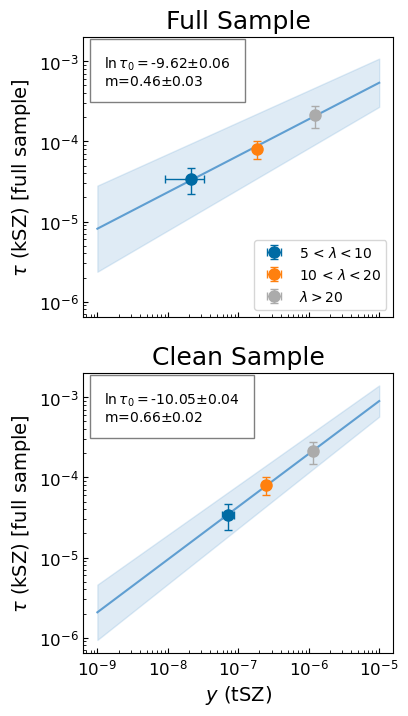

In [48]:
# --- Fonts / style ---
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})
m = 'ilc_db_1.6_10.7'
inds = ['', '_rc']
samps = ['full_sample', 'radio_clean']
labels = ['Full Sample', 'Clean Sample']
plotlabels = [r'5 < $\lambda < 10$', r'10 < $\lambda < 20$', r'$\lambda > 20$']
lums = ['L5D', 'L10D', 'L20']

fig, axs = plt.subplots(2, 1, figsize=(4, 8), sharex=True, sharey=True)
figure_data = pd.DataFrame()
for i, ind in enumerate(inds):
    axs[i].set_title(labels[i])
    samp = samps[i]
    mod = model[samp]
    for j, lum in enumerate(lums):
        axs[i].errorbar(figdata.loc[lum+ind, m+'_y'], figdata.loc[lum+ind, m+'_tau'],xerr=figdata.loc[lum+ind, m+'_y_err'], yerr=figdata.loc[lum+ind, m+'_tau_err'],label=plotlabels[j], **errbar_kwargs)
    axs[i].plot(mod['y_model'], mod['taufit'], color=colors[4])
    axs[i].fill_between(mod['y_model'], mod['t_low'], mod['t_high'], alpha=0.2, color=colors[4])
    popt = mod['popt']
    stds = mod['stds']
    axs[i].text(1.25e-9, 5e-4, r'$\ln\tau_0=$'+f'{popt[0]:.2f}'+r'$\pm$'+f'{stds[0]:.2f}'+'\n'+f'm={popt[1]:.2f}'+r'$\pm$'+f'{stds[1]:.2f}', fontsize=10,bbox={'facecolor': 'white', 'alpha': 0.5, 'pad': 10})

for ax in axs:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set_ylabel(r'$\tau\ (\mathrm{kSZ})$ [full sample]', fontsize=14)

axs[1].set_xlabel(r'$y\ (\mathrm{tSZ})$', fontsize=14)

axs[0].legend(loc='lower right',fontsize=10, frameon=True)
plt.savefig('figures/Figure16.pdf', bbox_inches='tight', pad_inches=0.1)

# Figure 17

In [5]:
figdata = {}
figdata['lrg'] = pd.read_csv('figure_data/figure17_lrg.csv', index_col=0)
figdata['bgs'] = pd.read_csv('figure_data/figure17_bgs.csv', index_col=0)
figdata['opt'] = pd.read_csv('figure_data/figure17_opt.csv', index_col=0)

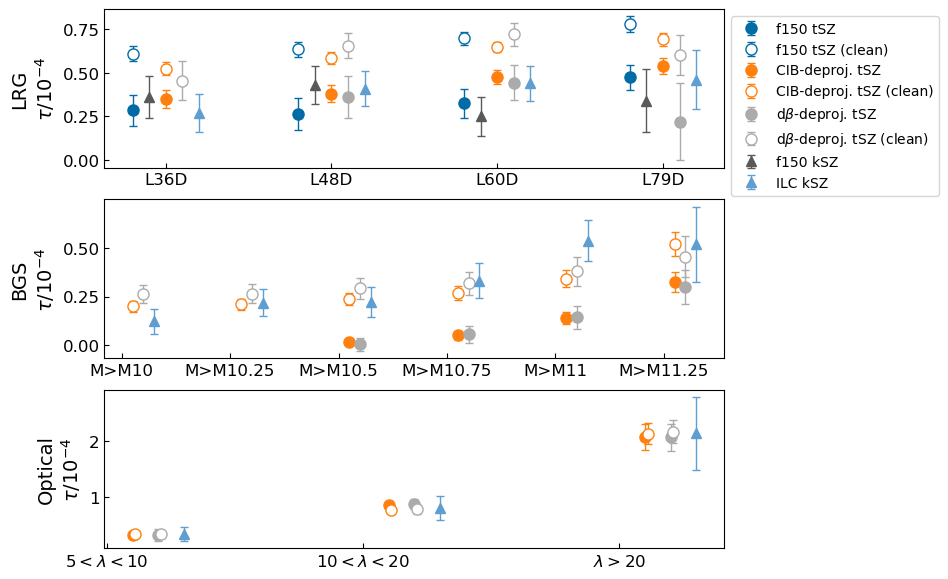

In [23]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
fig, axs = plt.subplots(3, 1, figsize=[8,7], sharex=False, sharey=False)
inds = ['', '_rc']
labels = ['', '(clean)']
mfcs = [None, 'white']
names = ['f150 tSZ ', 'CIB-deproj. tSZ ', r'd$\beta$-deproj. tSZ ', 'f150 kSZ ', 'ILC kSZ ']
lums = {}
lums['lrg'] = ['L36D', 'L48D', 'L60D', 'L79D']
lums['bgs'] = ['M10', 'M10.25', 'M10.5', 'M10.75', 'M11', 'M11.25']
lums['opt'] = ['L5D', 'L10D', 'L20']
maps = {}
maps['lrg'] = ['f150', 'ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']
maps['bgs'] = maps['opt'] = ['ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']

skips = [0, 0.2, 0.3]
samples = ['lrg', 'bgs', 'opt']
for s, samp in enumerate(samples):
    for j, m in enumerate(maps[samp]):
        for i, lum in enumerate(lums[samp]):
            for k, ind in enumerate(inds):
                index = j if samp=='lrg' else j+1
                combined_err = figdata[samp].loc[lum+ind, m+'_tsz_tau_staterr']+figdata[samp].loc[lum+ind, m+'_tsz_tau_syserr']
                if samp=='opt' and ind=='_rc':
                    axs[s].errorbar(i+skips[index]+0.01, figdata[samp].loc[lum+ind, m+'_tsz_tau']/1e-4, yerr=combined_err/1e-4, color=colors[index], mfc=mfcs[k], label=names[index]+labels[k], **errbar_kwargs)
                else:
                    axs[s].errorbar(i+skips[index], figdata[samp].loc[lum+ind, m+'_tsz_tau']/1e-4, yerr=combined_err/1e-4, color=colors[index], mfc=mfcs[k], label=names[index]+labels[k], **errbar_kwargs)

    for i, lum in enumerate(lums[samp]):
        if samp == 'lrg':
            axs[s].errorbar(i+0.1, figdata[samp].loc[lum+ind, 'f150_ksz_tau']/1e-4, yerr=figdata[samp].loc[lum+ind, 'f150_ksz_tau_err']/1e-4, color=colors[3], label=names[3], **errbar_kwargs_tri)
        axs[s].errorbar(i+0.4, figdata[samp].loc[lum+ind, 'ilc_ksz_tau']/1e-4, figdata[samp].loc[lum+ind, 'ilc_ksz_tau_err']/1e-4, color=colors[4], label=names[4], **errbar_kwargs_tri)
axs[0].set_ylabel('LRG\n'+r'$\tau /10^{-4}$')
axs[0].set_xticks(np.arange(len(lums['lrg']))+0.2, lums['lrg'])
handles, labels = axs[0].get_legend_handles_labels()
legend_inds = [0,1,8,9,16,17,24,25]
handles = [handles[i] for i in legend_inds]
labels = [labels[i] for i in legend_inds]
axs[0].legend(handles=handles, labels=labels, bbox_to_anchor=[1,1])
axs[1].set_ylabel('BGS\n'+r'$\tau /10^{-4}$')
axs[1].set_xticks(np.arange(len(lums['bgs']))+0.1, [f'M>{l}' for l in lums['bgs']])
axs[2].set_ylabel('Optical\n'+r'$\tau /10^{-4}$')
axs[2].set_xticks(np.arange(3)+0.1, [r'$5<\lambda<10$',r'$10<\lambda<20$', r'$\lambda>20$'])
plt.savefig('figures/Figure17.pdf', bbox_inches='tight', pad_inches=0.1)

# Figure 18

In [25]:
nonrotated_image = fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_act-planck_dr6.02_coadd_AA_night_f150_map_L35_stack.fits')
rotated_image = fits.getdata('/hpc/group/cosmology/jem189/scratch/data/stacks/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_act-planck_dr6.02_coadd_AA_night_f150_map_L35_stack_rotated.fits')

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


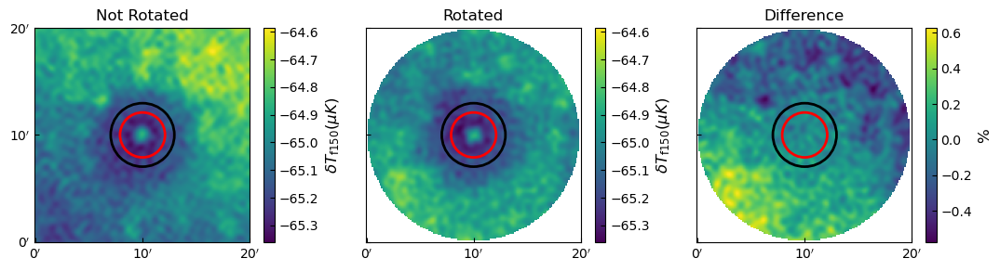

In [33]:
# --- ApJ-style rcParams ---
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
lum = 'L36'
fig, axs = plt.subplots(1, 3, figsize=[13, 3], sharex=True, sharey=True)
mins = [np.min(nonrotated_image), np.nanmin(rotated_image)]
maxs = [np.max(nonrotated_image), np.nanmax(rotated_image)]
cbar_norm = Normalize(vmin=np.min(mins), vmax=np.max(maxs))
difference_image = (nonrotated_image-rotated_image)/nonrotated_image
r_rad_submap = np.deg2rad(10/60.)
pixel_size = (r_rad_submap*2/np.shape(nonrotated_image)[0])*10800/np.pi
titles = ['Not Rotated', 'Rotated', 'Difference']
for i, image in enumerate([nonrotated_image, rotated_image]):
    im = axs[i].imshow(image, origin='lower', norm=cbar_norm)
    plt.colorbar(im, ax=axs[i], label=r'$\delta T_{\mathrm{f150}} (\mu K)$')
    disk = plt.Circle((np.shape(image)[0]/2., np.shape(image)[1]/2.), 2.1/pixel_size, color='red', fill=False, lw=2)
    disk2 = plt.Circle((np.shape(image)[0]/2., np.shape(image)[1]/2.), 2.1*np.sqrt(2)/pixel_size, color='black', fill=False, lw=2)
    axs[i].add_patch(disk)
    axs[i].add_patch(disk2)

im = axs[2].imshow(100*difference_image, origin='lower')
plt.colorbar(im, ax=axs[2], label=r'%')
disk = plt.Circle((np.shape(nonrotated_image)[0]/2., np.shape(nonrotated_image)[1]/2.), 2.1/pixel_size, color='red', fill=False, lw=2)
disk2 = plt.Circle((np.shape(nonrotated_image)[0]/2., np.shape(nonrotated_image)[1]/2.), 2.1*np.sqrt(2)/pixel_size, color='black', fill=False, lw=2)
axs[2].add_patch(disk)
axs[2].add_patch(disk2)
for ax in axs:
    ax.set_xticks(np.arange(0, 25, 10)/pixel_size, [fr"{n}$'$" for n in np.arange(0, 25, 10)])
    ax.set_yticks(np.arange(0, 25, 10)/pixel_size, [fr"{n}$'$" for n in np.arange(0, 25, 10)])
for i, ax in enumerate(axs):
    axs[i].set_title(titles[i])
plt.savefig('figures/Figure18.pdf', bbox_inches='tight')

In [34]:
np.savez('figure_data/figure18.npz', nonrotated_image=nonrotated_image, rotated_image=rotated_image, difference_image=difference_image)

# Figure 19

In [84]:
def get_profile_data(file, ycol, yerrcol):
    df = pd.read_csv(file, index_col=0)
    radii = list(df['radius'].values)
    dy = list(df[ycol].values)
    dy_err = list(df[yerrcol].values)
    return radii, dy, dy_err

samps = ['lrg', 'bgs', 'opt']

bins = {}
bins['lrg'] = ['L36', 'L48', 'L60', 'L79', 'L98', 'L36D', 'L48D', 'L60D', 'L79D']
bins['bgs'] = ['M10', 'M10.25', 'M10.5', 'M10.75', 'M11', 'M11.25']
bins['opt'] = ['L5', 'L10', 'L20']


profile_data = {}
for samp in samps:
    profile_data[samp] = {}
    for f in ['f090', 'f150']:
        profile_data[samp][f] = {}
        for lum in bins[samp]:
            profile_data[samp][f][lum] = {}
            profile_data[samp][f][lum]['radii'], profile_data[samp][f][lum]['dy'], profile_data[samp][f][lum]['dy_err'] = get_profile_data(f'profiles/{f}_{samp}_{lum}_profiles.csv', 'dy_bc', 'dy_err_bc')

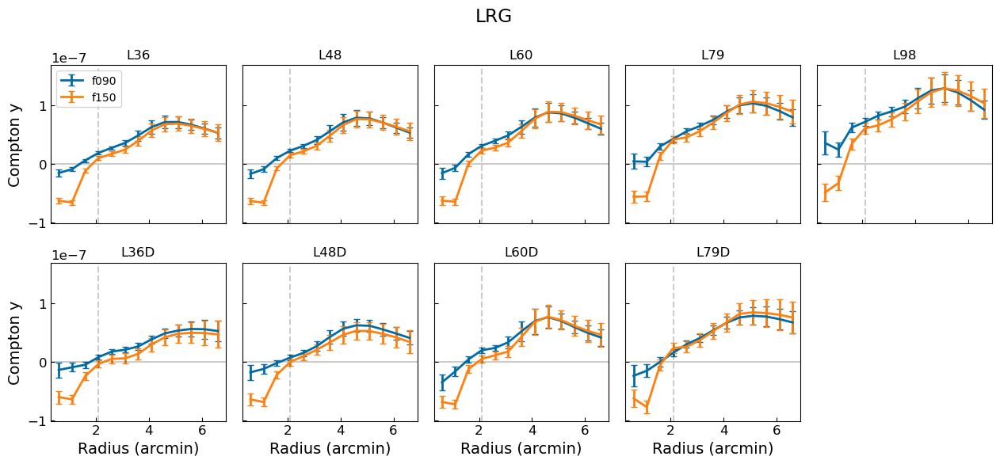

In [85]:
# LRG plot
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

samp = 'lrg'
ap = 2.1
labels = ['f090', 'f150']
cumulative_bins = ['L36', 'L48', 'L60', 'L79', 'L98']
disjoint_bins = ['L36D', 'L48D', 'L60D', 'L79D']
fig, axs = plt.subplots(2, 5, figsize=[13, 6], sharex=True, sharey=True)
for j, lum in enumerate(cumulative_bins):
    for i, k in enumerate(labels):
        axs[0,j].errorbar(profile_data[samp][k][lum]['radii'], profile_data[samp][k][lum]['dy'], yerr=profile_data[samp][k][lum]['dy_err'], label=labels[i], lw=2, capsize=3)
        axs[0,j].set_title(lum)
    axs[0,j].axvline(ap, ls='--', color='black', alpha=0.2)
    axs[0,j].axhline(0, color='black', alpha=0.2)
for j, lum in enumerate(disjoint_bins):
    for i, k in enumerate(labels):
        axs[1,j].errorbar(profile_data[samp][k][lum]['radii'], profile_data[samp][k][lum]['dy'], yerr=profile_data[samp][k][lum]['dy_err'], label=labels[i], lw=2, capsize=3)
        axs[1,j].set_title(lum)
    axs[1,j].axvline(ap, ls='--', color='black', alpha=0.2)
    axs[1,j].axhline(0, color='black', alpha=0.2)
    axs[1, j].set_xlabel('Radius (arcmin)')
for ax in axs[:, 0]:
    ax.set_ylabel('Compton y')
plt.suptitle('LRG')
plt.delaxes(axs[-1,-1])
plt.tight_layout()
axs[0,0].legend(loc='upper left')
plt.savefig(f'figures/Figure19_{samp}.pdf', bbox_inches='tight')

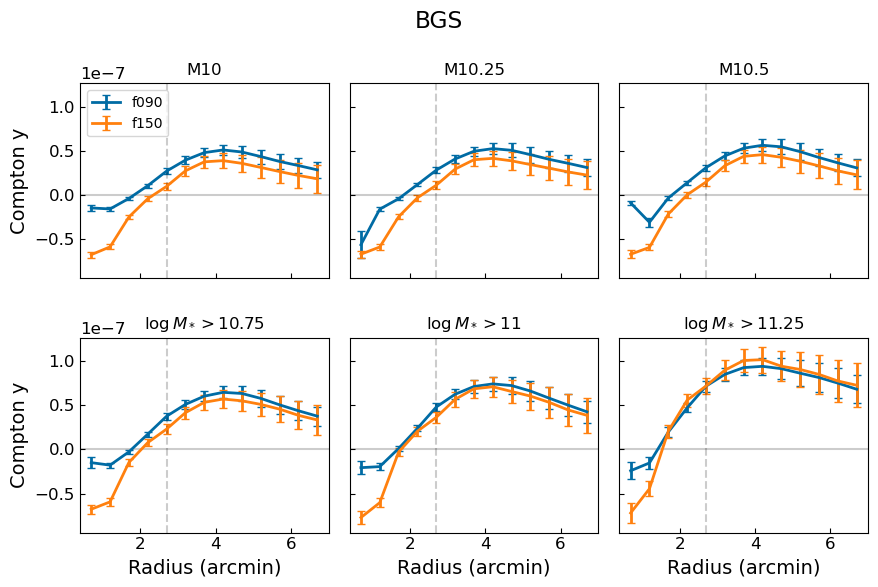

In [86]:
# BGS plot

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
samp = 'bgs'
ap = 2.7
labels=['f090', 'f150']
fig, axs = plt.subplots(2, 3, figsize=[9, 6], sharex=True, sharey=True)
for j, lum in enumerate(bins['bgs'][0:3]):
    for i, k in enumerate(labels):
        axs[0,j].errorbar(profile_data[samp][k][lum]['radii'], profile_data[samp][k][lum]['dy'], yerr=profile_data[samp][k][lum]['dy_err'], label=labels[i], lw=2, capsize=3)
        axs[0,j].set_title(lum)
    axs[0,j].axvline(ap, ls='--', color='black', alpha=0.2)
    axs[0,j].axhline(0, color='black', alpha=0.2)
for j, lum in enumerate(bins['bgs'][3:]):
    for i, k in enumerate(labels):
        axs[1,j].errorbar(profile_data[samp][k][lum]['radii'], profile_data[samp][k][lum]['dy'], yerr=profile_data[samp][k][lum]['dy_err'], label=labels[i], lw=2, capsize=3)
        axs[1,j].set_title(r'$\log M_* >$'+lum[1:])
    axs[1,j].axvline(ap, ls='--', color='black', alpha=0.2)
    axs[1,j].axhline(0, color='black', alpha=0.2)
    axs[1, j].set_xlabel('Radius (arcmin)')
for ax in axs[:, 0]:
    ax.set_ylabel('Compton y')
plt.suptitle('BGS')
plt.tight_layout()
axs[0,0].legend(loc='upper left')
plt.savefig(f'figures/Figure19_{samp}.pdf', bbox_inches='tight')

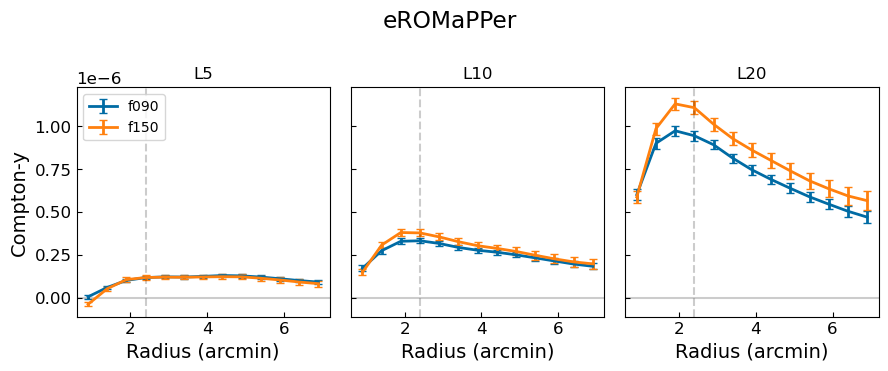

In [87]:
# eROMaPPer plot
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
samp = 'opt'
ap = 2.4
labels=['f090', 'f150']
titles = ['$\lambda>5$', r'$\lambda>10$', r'$\lambda>20$']
fig, axs = plt.subplots(1, 3, figsize=[9, 3.8], sharex=True, sharey=True)
for j, lum in enumerate(bins[samp]):
    for i, k in enumerate(labels):
        axs[j].errorbar(profile_data[samp][k][lum]['radii'], profile_data[samp][k][lum]['dy'], yerr=profile_data[samp][k][lum]['dy_err'], label=labels[i], lw=2, capsize=3)
        axs[j].set_title(lum)
    axs[j].axvline(ap, ls='--', color='black', alpha=0.2)
    axs[j].axhline(0, color='black', alpha=0.2)
    axs[j].set_xlabel('Radius (arcmin)')

axs[0].set_ylabel('Compton-y')
plt.suptitle('eROMaPPer')
axs[0].legend(loc='upper left')
plt.tight_layout()

plt.savefig(f'figures/Figure19_{samp}.pdf', bbox_inches='tight')

In [76]:
with open('figure_data/figure19.json', 'w') as file:
    json.dump(profile_data, file, indent=4)

# Figure 20

In [88]:
def get_profile_data(file, ycol, yerrcol):
    df = pd.read_csv(file, index_col=0)
    radii = list(df['radius'].values)
    dy = list(df[ycol].values)
    dy_err = list(df[yerrcol].values)
    return radii, dy, dy_err

samps = ['lrg', 'bgs', 'opt']

bins = {}
bins['lrg'] = ['L36', 'L48', 'L60', 'L79', 'L98', 'L36D', 'L48D', 'L60D', 'L79D']
bins['bgs'] = ['M10', 'M10.25', 'M10.5', 'M10.75', 'M11', 'M11.25']
bins['opt'] = ['L5', 'L10', 'L20']


profile_data = {}
for samp in samps:
    profile_data[samp] = {}
    for f in ['ilc', 'ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']:
        profile_data[samp][f] = {}
        for lum in bins[samp]:
            profile_data[samp][f][lum] = {}
            profile_data[samp][f][lum]['radii'], profile_data[samp][f][lum]['dy'], profile_data[samp][f][lum]['dy_err'] = get_profile_data(f'profiles/{f}_{samp}_{lum}_profiles.csv', 'dy_bc', 'dy_err_bc')

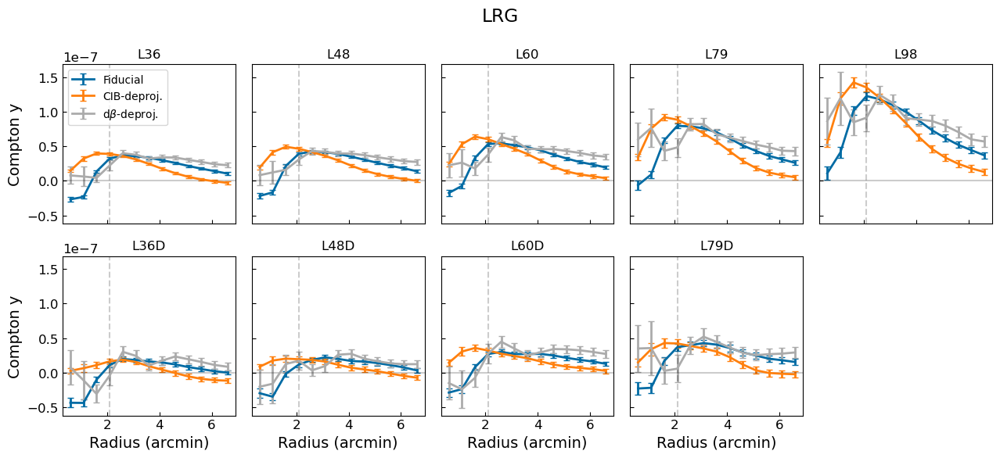

In [91]:
# LRG plot
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

samp = 'lrg'
ap = 2.1
labels = ['Fiducial', 'CIB-deproj.', r'd$\beta$-deproj.']
maps = ['ilc', 'ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']
cumulative_bins = ['L36', 'L48', 'L60', 'L79', 'L98']
disjoint_bins = ['L36D', 'L48D', 'L60D', 'L79D']
fig, axs = plt.subplots(2, 5, figsize=[13, 6], sharex=True, sharey=True)
for j, lum in enumerate(cumulative_bins):
    for i, k in enumerate(maps):
        axs[0,j].errorbar(profile_data[samp][k][lum]['radii'], profile_data[samp][k][lum]['dy'], yerr=profile_data[samp][k][lum]['dy_err'], label=labels[i], lw=2, capsize=3)
        axs[0,j].set_title(lum)
    axs[0,j].axvline(ap, ls='--', color='black', alpha=0.2)
    axs[0,j].axhline(0, color='black', alpha=0.2)
for j, lum in enumerate(disjoint_bins):
    for i, k in enumerate(maps):
        axs[1,j].errorbar(profile_data[samp][k][lum]['radii'], profile_data[samp][k][lum]['dy'], yerr=profile_data[samp][k][lum]['dy_err'], label=labels[i], lw=2, capsize=3)
        axs[1,j].set_title(lum)
    axs[1,j].axvline(ap, ls='--', color='black', alpha=0.2)
    axs[1,j].axhline(0, color='black', alpha=0.2)
    axs[1, j].set_xlabel('Radius (arcmin)')
for ax in axs[:, 0]:
    ax.set_ylabel('Compton y')
plt.suptitle('LRG')
plt.delaxes(axs[-1,-1])
plt.tight_layout()
axs[0,0].legend(loc='upper left')
plt.savefig(f'figures/Figure20_{samp}.pdf', bbox_inches='tight')

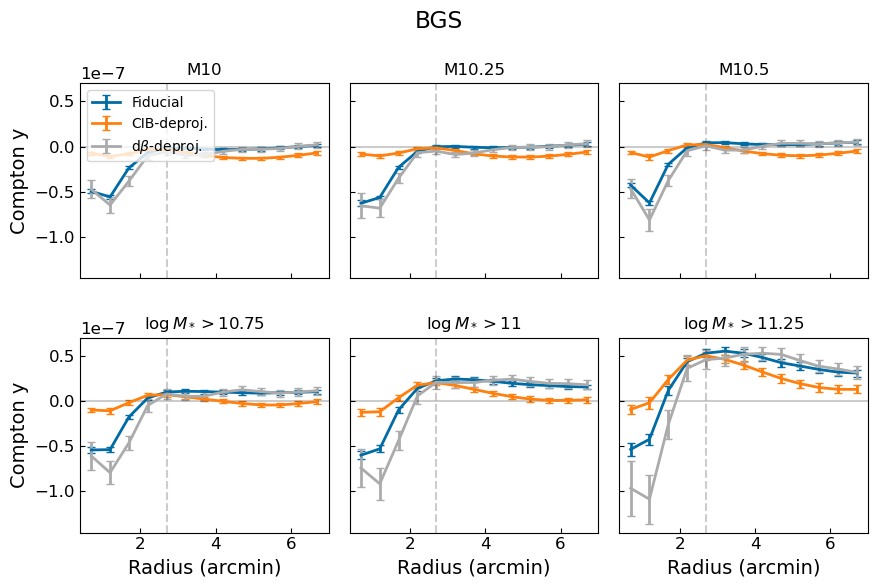

In [93]:
# BGS plot

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
samp = 'bgs'
ap = 2.7
labels = ['Fiducial', 'CIB-deproj.', r'd$\beta$-deproj.']
maps = ['ilc', 'ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']
fig, axs = plt.subplots(2, 3, figsize=[9, 6], sharex=True, sharey=True)
for j, lum in enumerate(bins['bgs'][0:3]):
    for i, k in enumerate(maps):
        axs[0,j].errorbar(profile_data[samp][k][lum]['radii'], profile_data[samp][k][lum]['dy'], yerr=profile_data[samp][k][lum]['dy_err'], label=labels[i], lw=2, capsize=3)
        axs[0,j].set_title(lum)
    axs[0,j].axvline(ap, ls='--', color='black', alpha=0.2)
    axs[0,j].axhline(0, color='black', alpha=0.2)
for j, lum in enumerate(bins['bgs'][3:]):
    for i, k in enumerate(maps):
        axs[1,j].errorbar(profile_data[samp][k][lum]['radii'], profile_data[samp][k][lum]['dy'], yerr=profile_data[samp][k][lum]['dy_err'], label=labels[i], lw=2, capsize=3)
        axs[1,j].set_title(r'$\log M_* >$'+lum[1:])
    axs[1,j].axvline(ap, ls='--', color='black', alpha=0.2)
    axs[1,j].axhline(0, color='black', alpha=0.2)
    axs[1, j].set_xlabel('Radius (arcmin)')
for ax in axs[:, 0]:
    ax.set_ylabel('Compton y')
plt.suptitle('BGS')
plt.tight_layout()
axs[0,0].legend(loc='upper left')
plt.savefig(f'figures/Figure20_{samp}.pdf', bbox_inches='tight')

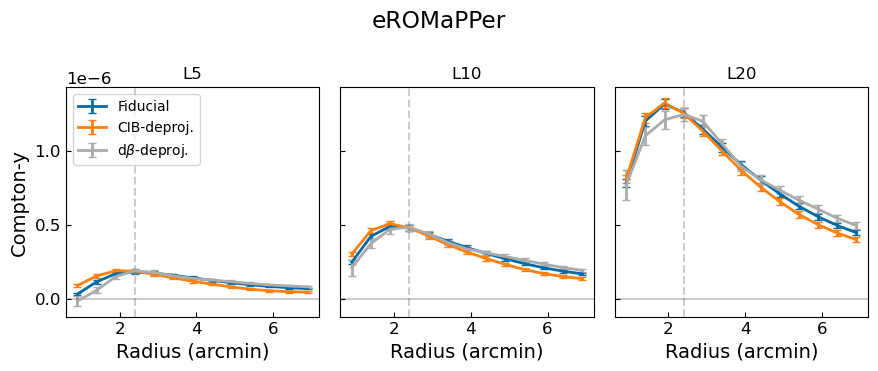

In [94]:
# eROMaPPer plot
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
samp = 'opt'
ap = 2.4
labels = ['Fiducial', 'CIB-deproj.', r'd$\beta$-deproj.']
maps = ['ilc', 'ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']
titles = ['$\lambda>5$', r'$\lambda>10$', r'$\lambda>20$']
fig, axs = plt.subplots(1, 3, figsize=[9, 3.8], sharex=True, sharey=True)
for j, lum in enumerate(bins[samp]):
    for i, k in enumerate(maps):
        axs[j].errorbar(profile_data[samp][k][lum]['radii'], profile_data[samp][k][lum]['dy'], yerr=profile_data[samp][k][lum]['dy_err'], label=labels[i], lw=2, capsize=3)
        axs[j].set_title(lum)
    axs[j].axvline(ap, ls='--', color='black', alpha=0.2)
    axs[j].axhline(0, color='black', alpha=0.2)
    axs[j].set_xlabel('Radius (arcmin)')

axs[0].set_ylabel('Compton-y')
plt.suptitle('eROMaPPer')
axs[0].legend(loc='upper left')
plt.tight_layout()

plt.savefig(f'figures/Figure20_{samp}.pdf', bbox_inches='tight')

In [95]:
with open('figure_data/figure20.json', 'w') as file:
    json.dump(profile_data, file, indent=4)

# Tables

In [96]:
catalogs = {}
catalogs['lrg_sf'] = pd.read_csv('/work/jem189/scratch/data/catalogs/ACT_DR6_DESI_Y1Iron_LRGs_10242025_valid_radioflagged.csv')
catalogs['lrg_ilc'] = pd.read_csv('/work/jem189/scratch/data/catalogs/ACT_DR6_DESI_Y1Iron_LRGs_11122025_valid_ilc_radioflagged.csv')
catalogs['bgs'] = pd.read_csv('/work/jem189/scratch/data/catalogs/BGS_BRIGHT_full_noveto_vac_marvin_BGS_ACT_DR6_fixedTh2.10_delta_Ts_radioflagged.csv')
catalogs['opt'] = pd.read_csv('/work/jem189/scratch/data/catalogs/iskay_RM_ls10_iron_v1_CGz_cat_310525_radioflagged.csv')

# Table I

In [119]:
lrg_bins = ['L36', 'L48', 'L60', 'L79', 'L98', 'L36D', 'L48D', 'L60D', 'L79D']
# lcuts and mcuts from Gong et al. 2026 Table I
upper_lcuts = {'L36':None, 'L48':None, 'L60':None, 'L79':None, 'L98':None, 'L36D':4.78, 'L48D':5.98, 'L60D':7.86, 'L79D':9.80}
lower_lcuts = {'L36':3.58, 'L48':4.78, 'L60':5.98, 'L79':7.86, 'L98':9.8, 'L36D':3.58, 'L48D':4.78, 'L60D':5.98, 'L79D':7.86}
upper_mcuts = {'L36':None, 'L48':None, 'L60':None, 'L79':None, 'L98':None, 'L36D':0.63, 'L48D':0.96, 'L60D':1.64, 'L79D':2.59}
lower_mcuts = {'L36':0.38, 'L48':0.63, 'L60':0.96, 'L79':1.64, 'L98':2.59, 'L36D':0.38, 'L48D':0.63, 'L60D':0.96, 'L79D':1.64}
table = pd.DataFrame()
for lum in lrg_bins:
    with open(f'paramfiles/f090_lrg_{lum}.json', 'r') as f:
        params = json.load(f)
    cat_ilc_queried = catalogs['lrg_ilc'].query(params['query'])
    table.loc[lum, 'Lmin/10^10Lsun'] = lower_lcuts[lum]
    table.loc[lum, 'Lmax/10^10Lsun'] = upper_lcuts[lum]
    table.loc[lum, 'Mvir_min/10^13Msun'] = lower_mcuts[lum]
    table.loc[lum, 'Mvir_max/10^13Msun'] = upper_mcuts[lum]
    table.loc[lum, '<logM*/Msun>'] = np.log10(np.average(cat_ilc_queried['Mstar']))
    table.loc[lum, '<L/10^10Lsun>'] = np.average(cat_ilc_queried['lum'])/1e10
    table.loc[lum, '<z>'] = np.average(cat_ilc_queried['z'])
    table.loc[lum, 'N_ilc'] = len(cat_ilc_queried)
    table.loc[lum, 'N_f150'] = len(catalogs['lrg_sf'].query(params['query']))

table.to_csv('table_data/table1.csv')
table

,Lmin/10^10Lsun,Lmax/10^10Lsun,Mvir_min/10^13Msun,Mvir_max/10^13Msun,<logM*/Msun>,<L/10^10Lsun>,<z>,N_ilc,N_f150
L36,3.58,None,0.38,None,11.315556,6.893427,0.758520,913286.0,957095.0
L48,4.78,None,0.63,None,11.368376,7.784931,0.776710,685766.0,718542.0
L60,5.98,None,0.96,None,11.431460,9.001989,0.804206,456803.0,478585.0
L79,7.86,None,1.64,None,11.525689,11.183238,0.844841,228650.0,239567.0
L98,9.80,None,2.59,None,11.612874,13.669495,0.877624,114024.0,119353.0
L36D,3.58,4.78,0.38,0.63,11.101027,4.206351,0.703694,227520.0,238553.0
L48D,4.78,5.98,0.63,0.96,11.206025,5.356784,0.721854,228963.0,239957.0
L60D,5.98,7.86,0.96,1.64,11.310650,6.815989,0.763482,228153.0,239018.0
L79D,7.86,9.8,1.64,2.59,11.417141,8.710038,0.812229,114626.0,120214.0


# Table II

In [121]:
bgs_bins = ['M10', 'M10.25', 'M10.5', 'M10.75', 'M11', 'M11.25']
mhalos = {'M10':13.135, 'M10.25':13.184, 'M10.5':13.266, 'M10.75':13.31, 'M11':13.37, 'M11.25':13.456} # from Hadzhyiska et al. 2025 Table I
table = pd.DataFrame()
for lum in bgs_bins:
    with open(f'paramfiles/f090_bgs_{lum}.json', 'r') as f:
        params = json.load(f)
    cat_queried = catalogs['bgs'].query(params['query'])
    table.loc[lum, '<logM*/Msun>'] = np.average(cat_queried['logm'])
    table.loc[lum, '<logMh>'] = mhalos[lum]
    table.loc[lum, '<z>'] = np.average(cat_queried['z'])
    table.loc[lum, 'N'] = len(cat_queried)

table.to_csv('table_data/table2.csv')
table

,<logM*/Msun>,<logMh>,<z>,N
M10,10.721400,13.135,0.254412,1610381.0
M10.25,10.820422,13.184,0.265726,1379230.0
M10.5,10.940387,13.266,0.281085,1084339.0
M10.75,11.083850,13.310,0.302039,744562.0
M11,11.246573,13.370,0.329747,421150.0
M11.25,11.424901,13.456,0.364737,178206.0


# Table III

In [123]:
opt_bins = ['L5', 'L10', 'L20']
# richnesses and masses from Yun-Hsin
lambda_des = {'L5':11.28, 'L10':18.92, 'L20':32.71}
m200 = {'L5':13.77, 'L10':14.01, 'L20':14.26}

table = pd.DataFrame()
for lum in opt_bins:
    with open(f'paramfiles/f090_opt_{lum}.json', 'r') as f:
        params = json.load(f)
    cat_queried = catalogs['opt'].query(params['query'])
    table.loc[lum, '<lambda_DES>'] = lambda_des[lum]
    table.loc[lum, '<logM200>'] = m200[lum]
    table.loc[lum, '<z>'] = np.average(cat_queried['z'])
    table.loc[lum, 'N'] = len(cat_queried)

table.to_csv('table_data/table3.csv')
table

,<lambda_DES>,<logM200>,<z>,N
L5,11.28,13.77,0.476680,220698.0
L10,18.92,14.01,0.478032,80447.0
L20,32.71,14.26,0.468255,22320.0


# Table V

In [130]:
opt_bins = ['L5D', 'L10D', ]
# richnesses from Yun-Hsin
lambda_des = {'L5D':5.44, 'L5D_rc':5.42, 'L10D':10.77, 'L10D_rc':10.70}

table = pd.DataFrame()
for lum in opt_bins:
    with open(f'paramfiles/ilc_opt_{lum}.json', 'r') as f:
        params = json.load(f)
    with open(f'paramfiles/ilc_opt_{lum}_radio_clean.json', 'r') as f:
        params_rc = json.load(f)
    table.loc[lum, '<N>'] = len(catalogs['opt'].query(params['query']))
    table.loc[lum+'_rc', '<N>'] = len(catalogs['opt'].query(params_rc['query']))
    table.loc[lum, '<z>'] = np.average(catalogs['opt'].query(params['query'])['z'])
    table.loc[lum+'_rc', '<z>'] = np.average(catalogs['opt'].query(params_rc['query'])['z'])
    table.loc[lum, '<lambda_DES>'] = lambda_des[lum]
    table.loc[lum+'_rc', '<lambda_DES>'] = lambda_des[lum+'_rc']
    
    for m in ['ilc_cib_1.6_10.7', 'ilc_db_1.6_10.7']:
        profiles = pd.read_csv(f'profiles/{m}_opt_{lum}_profiles.csv', index_col=0)
        table.loc[lum, m+'_y/10^-7'] = profiles[np.round(profiles['radius'], 1)==2.4]['dy'].values[0]/1e-7
        table.loc[lum, m+'_yerr/10^-7'] = profiles[np.round(profiles['radius'], 1)==2.4]['dy_err'].values[0]/1e-7
        profiles_rc = pd.read_csv(f'profiles/{m}_opt_{lum}_radio_clean_profiles.csv', index_col=0)
        table.loc[lum+'_rc', m+'_y/10^-7'] = profiles_rc[np.round(profiles_rc['radius'], 1)==2.4]['dy'].values[0]/1e-7
        table.loc[lum+'_rc', m+'_yerr/10^-7'] = profiles_rc[np.round(profiles_rc['radius'], 1)==2.4]['dy_err'].values[0]/1e-7

table.to_csv('table_data/table5.csv')
table

,<N>,<z>,<lambda_DES>,ilc_cib_1.6_10.7_y/10^-7,ilc_cib_1.6_10.7_yerr/10^-7,ilc_db_1.6_10.7_y/10^-7,ilc_db_1.6_10.7_yerr/10^-7
L5D,140251.0,0.475904,5.44,0.200117,0.055676,0.211525,0.119469
L5D_rc,100465.0,0.479771,5.42,0.680682,0.060563,0.723131,0.142438
L10D,58127.0,0.481786,10.77,1.773542,0.084851,1.850921,0.195740
L10D_rc,38519.0,0.488904,10.70,2.430076,0.096966,2.458271,0.234046


# Tables VII-IX

In [4]:
# Tables 7-9 consist of the data points shown in Figure 17
figdata = {}
figdata['lrg'] = pd.read_csv('figure_data/figure17_lrg.csv', index_col=0)
figdata['bgs'] = pd.read_csv('figure_data/figure17_bgs.csv', index_col=0)
figdata['opt'] = pd.read_csv('figure_data/figure17_opt.csv', index_col=0)

In [135]:
figdata['lrg']

,f150_tsz_tau,f150_tsz_tau_staterr,f150_tsz_tau_syserr,ilc_cib_1.6_10.7_tsz_tau,ilc_cib_1.6_10.7_tsz_tau_staterr,ilc_cib_1.6_10.7_tsz_tau_syserr,ilc_db_1.6_10.7_tsz_tau,ilc_db_1.6_10.7_tsz_tau_staterr,ilc_db_1.6_10.7_tsz_tau_syserr,f150_ksz_tau,f150_ksz_tau_err,ilc_ksz_tau,ilc_ksz_tau_err
L36D,0.000028,0.000008,1.370171e-06,0.000035,0.000004,1.344810e-06,NaN,0.000033,0.000000e+00,0.000036,0.000012,0.000027,0.000011
L36D_rc,0.000061,0.000003,9.868713e-07,0.000052,0.000003,1.143949e-06,0.000046,0.000010,1.244133e-06,0.000036,0.000012,0.000027,0.000011
L48D,0.000026,0.000008,1.352133e-06,0.000038,0.000003,1.345344e-06,0.000036,0.000011,1.349435e-06,0.000043,0.000011,0.000041,0.000010
L48D_rc,0.000064,0.000003,9.353784e-07,0.000058,0.000002,1.029250e-06,0.000066,0.000006,8.910604e-07,0.000043,0.000011,0.000041,0.000010
L60D,0.000033,0.000007,1.372166e-06,0.000048,0.000003,1.237873e-06,0.000044,0.000009,1.261297e-06,0.000025,0.000011,0.000044,0.000010
L60D_rc,0.000070,0.000003,8.320764e-07,0.000065,0.000002,9.160177e-07,0.000072,0.000006,8.145676e-07,0.000025,0.000011,0.000044,0.000010
L79D,0.000047,0.000006,1.214632e-06,0.000054,0.000003,1.111545e-06,0.000022,0.000021,1.292251e-06,0.000034,0.000018,0.000046,0.000017
L79D_rc,0.000078,0.000004,7.885733e-07,0.000069,0.000003,8.501460e-07,0.000060,0.000010,1.001012e-06,0.000034,0.000018,0.000046,0.000017


In [136]:
figdata['bgs']

,ilc_cib_1.6_10.7_tsz_tau,ilc_cib_1.6_10.7_tsz_tau_staterr,ilc_cib_1.6_10.7_tsz_tau_syserr,ilc_db_1.6_10.7_tsz_tau,ilc_db_1.6_10.7_tsz_tau_staterr,ilc_db_1.6_10.7_tsz_tau_syserr,ilc_ksz_tau,ilc_ksz_tau_err
M10,NaN,0.000001,0.000000e+00,NaN,0.000003,0.000000e+00,0.000012,0.000006
M10_rc,0.000020,0.000001,1.564710e-06,2.616707e-05,0.000003,1.863909e-06,0.000012,0.000006
M10.25,NaN,0.000001,0.000000e+00,NaN,0.000003,0.000000e+00,0.000022,0.000007
M10.25_rc,0.000021,0.000001,1.614614e-06,2.656078e-05,0.000003,1.881841e-06,0.000022,0.000007
M10.5,0.000002,0.000001,3.269978e-07,7.027055e-07,0.000003,1.539344e-07,0.000022,0.000008
M10.5_rc,0.000024,0.000001,1.740775e-06,2.918101e-05,0.000003,1.990813e-06,0.000022,0.000008
M10.75,0.000005,0.000002,6.765487e-07,5.767910e-06,0.000004,7.160457e-07,0.000033,0.000009
M10.75_rc,0.000027,0.000002,1.876369e-06,3.187267e-05,0.000004,2.123470e-06,0.000033,0.000009
M11,0.000014,0.000002,1.253589e-06,1.433369e-05,0.000004,1.308314e-06,0.000054,0.000011
M11_rc,0.000034,0.000002,2.252150e-06,3.803400e-05,0.000005,2.412726e-06,0.000054,0.000011


In [137]:
figdata['opt']

,ilc_cib_1.6_10.7_tsz_tau,ilc_cib_1.6_10.7_tsz_tau_staterr,ilc_cib_1.6_10.7_tsz_tau_syserr,ilc_db_1.6_10.7_tsz_tau,ilc_db_1.6_10.7_tsz_tau_staterr,ilc_db_1.6_10.7_tsz_tau_syserr,ilc_ksz_tau,ilc_ksz_tau_err
L5D,0.000032,0.000004,0.000003,0.000033,0.000007,0.000003,0.000034,0.000012
L5D_rc,0.000033,0.000002,0.000001,0.000035,0.000004,0.000001,0.000034,0.000012
L10D,0.000086,0.000002,0.000005,0.000088,0.000004,0.000006,0.000081,0.000021
L10D_rc,0.000077,0.000002,0.000003,0.000078,0.000005,0.000003,0.000081,0.000021
L20,0.000206,0.000002,0.000021,0.000206,0.000003,0.000021,0.000213,0.000065
L20_rc,0.000212,0.000004,0.000014,0.000216,0.000006,0.000015,0.000213,0.000065
